# Download Dataset

In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khnhhunhnguynvn","key":"5071bbbf57ff8cb9794016bacafcd6c7"}'}

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download 'parisrohan/credit-score-classification'

 84% 8.00M/9.51M [00:01<00:00, 8.89MB/s]
100% 9.51M/9.51M [00:01<00:00, 5.54MB/s]


In [ ]:
# !unzip creditscoreclassification.zip
!unzip credit-score-classification.zip

Archive:  credit-score-classification.zip
  inflating: test.csv                
  inflating: train.csv               


# Import Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score,
                             recall_score,
                             accuracy_score,
                             precision_score,
                             confusion_matrix,
                             classification_report,
                             ConfusionMatrixDisplay,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re

# Clean Data

## Load data

In [ ]:
df_train = pd.read_csv("train.csv")
print(df_train.shape)
df_train.info()

<ipython-input-8-ac029fb29d1b>:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("train.csv")


(100000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 

In [ ]:
df_test = pd.read_csv("test.csv")
print(df_test.shape)
df_test.info()

(50000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 

In [ ]:
df = pd.concat([df_train, df_test], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  object 
 1   Customer_ID               150000 non-null  object 
 2   Month                     150000 non-null  object 
 3   Name                      135000 non-null  object 
 4   Age                       150000 non-null  object 
 5   SSN                       150000 non-null  object 
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  object 
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  object 
 13  Type_of_Loan              132888 non-null  o

## Fix data type

In [ ]:
def text_cleaning(data):
    if data is np.NaN or not isinstance(data, str):
        return data
    else:
        return str(data).strip('_ ,"')

def Month_Converter(x):
    if pd.notnull(x):
        num1 = int(x.split(' ')[0])
        num2 = int(x.split(' ')[3])

        return (num1*12)+num2
    else:
        return x

def get_Diff_Values_Colum(df_column, diff_value=[], sep=',', replace=''):
    column = df_column.dropna()
    for i in column:
        if sep not in i and i not in diff_value:
            diff_value.append(i)
        else:
            for data in map(lambda x:x.strip(), re.sub(replace, '', i).split(sep)):
                if not data in diff_value:
                    diff_value.append(data)
    return dict(enumerate(sorted(diff_value)))

In [ ]:
df = df.applymap(text_cleaning).replace(['', 'nan', '!@9#%8', '#F%$D@*&8'], np.NaN)

In [ ]:
df['ID']                      = df.ID.apply(lambda x: int(x, 16))
df['Customer_ID']             = df.Customer_ID.apply(lambda x: int(x[4:], 16))
df['Month']                   = pd.to_datetime(df.Month, format='%B').dt.month
df['Age']                     = df.Age.astype(int)
df['SSN']                     = df.SSN.apply(lambda x: x if x is np.NaN else int(str(x).replace('-', ''))).astype(float)
df['Annual_Income']           = df.Annual_Income.astype(float)
df['Num_of_Loan']             = df.Num_of_Loan.astype(int)
df['Num_of_Delayed_Payment']  = df.Num_of_Delayed_Payment.astype(float)
df['Changed_Credit_Limit']    = df.Changed_Credit_Limit.astype(float)
df['Outstanding_Debt']        = df.Outstanding_Debt.astype(float)
df['Amount_invested_monthly'] = df.Amount_invested_monthly.astype(float)
df['Monthly_Balance']         = df.Monthly_Balance.astype(float)

In [ ]:
df['Credit_History_Age'] = df.Credit_History_Age.apply(lambda x: Month_Converter(x)).astype(float)
df['Type_of_Loan'] = (df['Type_of_Loan']
                      .apply(lambda x: x.lower()
                      .replace('and ', '')
                      .replace(', ', ',').strip() if pd.notna(x) else x))

In [ ]:
get_Diff_Values_Colum(df['Type_of_Loan'])

{0: 'auto loan',
 1: 'credit-builder loan',
 2: 'debt consolidation loan',
 3: 'home equity loan',
 4: 'mortgage loan',
 5: 'not specified',
 6: 'payday loan',
 7: 'personal loan',
 8: 'student loan'}

## Replace invalid value with and replace them with mode value

In [ ]:
def fill_nan_feature(df, column_name):
  most_common_names = df.groupby('Customer_ID')[column_name].agg(lambda x: x.mode()[0] if pd.notna(x).any() else np.NaN)

  # Replace NaN values with the most common name for each ID
  df[column_name] = df.apply(lambda row: most_common_names[row['Customer_ID']] if pd.isna(row[column_name]) else row[column_name], axis=1)

In [ ]:
df['Type_of_Loan'].replace([np.NaN], 'No Data', inplace=True)

In [ ]:
fill_nan_feature(df, 'Payment_Behaviour')
fill_nan_feature(df, 'Name')
fill_nan_feature(df, 'Occupation')
fill_nan_feature(df, 'Type_of_Loan')
fill_nan_feature(df, 'Credit_Mix')
fill_nan_feature(df, 'Payment_of_Min_Amount')

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265.0,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,-500,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265.0,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Customer_ID               150000 non-null  int64  
 2   Month                     150000 non-null  int64  
 3   Name                      150000 non-null  object 
 4   Age                       150000 non-null  int64  
 5   SSN                       141600 non-null  float64
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  float64
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  int64  
 13  Type_of_Loan              150000 non-null  o

In [ ]:
# Identify Wrong values Range
def get_group_min_max(df, groupby, column):
    cur = df[df[column].notna()].groupby(groupby)[column].apply(list);
    x, y = cur.apply(lambda x: stats.mode(x, keepdims=True)).apply([min, max])
    return x[0][0], y[0][0]

# Assigning Wrong values
def make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace=True):
    df_dropped = df[df[column].notna()].groupby(groupby)[column].apply(list);
    x, y = df_dropped.apply(lambda x: stats.mode(x, keepdims=True)).apply([min, max])
    mini, maxi = x[0][0], y[0][0]

    # assign Wrong Values to NaN
    col = df[column].apply(lambda x: np.NaN if ((x<mini)|(x>maxi)) else x)

    # fill with local mode
    mode_by_group = df.groupby(groupby)[column].transform(lambda x: x.mode()[0] if not x.mode().empty else np.NaN)
    result = col.fillna(mode_by_group)

    # inplace
    if inplace:
        df[column]=result
    else:
        return result


# Reassign Wrong Values and Show Function
def Numeric_Wrong_Values_Reassign_Group_Min_Max(df, groupby, column, inplace=True):
    if inplace:
        # Before Assigning NaN values
        if df[column].value_counts(dropna=False).index.isna().sum():
            x = df[column].value_counts(dropna=False).loc[[np.NaN]]
            print(f'\nBefore Assigning: {column}:', f'have {x.values[0]} NaN Values', end='\n')

        print("\nExisting Min, Max Values:", df[column].apply([min, max]), sep='\n', end='\n')
        mini, maxi = get_group_min_max(df, groupby, column)
        print(f"\nGroupby by {groupby}'s Actual min, max Values:", f'min:\t{mini},\nmax:\t{ maxi}', sep='\n', end='\n')

        a = df.groupby(groupby)[column].apply(list)
        print(f'\nBefore Assigning Example {column}:\n', *a.head().values, sep='\n', end='\n')

        # Assigning
        make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace)

        # After Assigning NaN values
        if df[column].value_counts(dropna=False).index.isna().sum():
            y = df[column].value_counts(dropna=False).loc[[np.NaN]]
            print(f'\nBefore Assigning: {column}:', f'have {y.values[0]} NaN Values', end='\n')

        b = df.groupby(groupby)[column].apply(list)
        print(f'\nAfter Assigning Example {column}:\n', *b.head().values, sep='\n', end='\n')
    else:
        # Show
        return make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace)

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Age')


Existing Min, Max Values:
min    -500
max    8698
Name: Age, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	14,
max:	56

Before Assigning Example Age:

[37, 38, 38, 8153, 38, 38, 38, 38, 38, 38, 38, 38]
[48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 49]
[3452, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
[22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23]
[43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44]

After Assigning Example Age:

[37.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0]
[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 49.0]
[37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0]
[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 23.0, 23.0, 23.0, 23.0, 23.0]
[43.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'SSN')


Before Assigning: SSN: have 8400 NaN Values

Existing Min, Max Values:
min        81349.0
max    999993421.0
Name: SSN, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	81349.0,
max:	999993421.0

Before Assigning Example SSN:

[354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, nan, 354656948.0]
[964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0]
[802194704.0, nan, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0]
[nan, nan, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0]
[422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Annual_Income')


Existing Min, Max Values:
min        7005.93
max    24198062.00
Name: Annual_Income, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	7005.93,
max:	179987.28

Before Assigning Example Annual_Income:

[16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18]
[21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91]
[33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43]
[80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64]
[104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56]

After Assigning Example Annual_Income:

[16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18]

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Inhand_Salary')


Before Assigning: Monthly_Inhand_Salary: have 22500 NaN Values

Existing Min, Max Values:
min      303.645417
max    15204.633333
Name: Monthly_Inhand_Salary, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	303.6454166666666,
max:	15204.633333333331

Before Assigning Example Monthly_Inhand_Salary:

[1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, nan, 1331.3483333333334]
[1496.7425, 1496.7425, 1496.7425, 1496.7425, nan, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425]
[2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333]
[6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666,

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Bank_Accounts')


Existing Min, Max Values:
min      -1
max    1798
Name: Num_Bank_Accounts, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	-1,
max:	11

Before Assigning Example Num_Bank_Accounts:

[9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
[3, 3, 3, 1174, 3, 3, 3, 3, 3, 3, 3, 3]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

After Assigning Example Num_Bank_Accounts:

[9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Card')


Existing Min, Max Values:
min       0
max    1499
Name: Num_Credit_Card, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	0,
max:	11

Before Assigning Example Num_Credit_Card:

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 750]
[4, 4, 4, 4, 4, 4, 4, 888, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 112]
[3, 3, 3, 3, 725, 3, 3, 3, 3, 3, 3, 3]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

After Assigning Example Num_Credit_Card:

[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Interest_Rate')


Existing Min, Max Values:
min       1
max    5799
Name: Interest_Rate, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	1,
max:	34

Before Assigning Example Interest_Rate:

[22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]
[15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

After Assigning Example Interest_Rate:

[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0]
[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0]
[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Loan')


Existing Min, Max Values:
min    -100
max    1496
Name: Num_of_Loan, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	0,
max:	9

Before Assigning Example Num_of_Loan:

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -100]
[3, 3, 3, 3, -100, 3, 3, 3, 3, 3, 3, 3]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

After Assigning Example Num_of_Loan:

[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Delay_from_due_date')


Existing Min, Max Values:
min    -5
max    67
Name: Delay_from_due_date, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	-1,
max:	62

Before Assigning Example Delay_from_due_date:

[48, 48, 48, 48, 48, 48, 48, 48, 48, 50, 48, 53]
[19, 19, 19, 19, 19, 19, 19, 16, 20, 19, 15, 19]
[25, 28, 22, 26, 26, 26, 26, 26, 26, 26, 21, 26]
[19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 21, 19]
[15, 15, 20, 16, 20, 20, 20, 24, 25, 20, 20, 20]

After Assigning Example Delay_from_due_date:

[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 50.0, 48.0, 53.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 16.0, 20.0, 19.0, 15.0, 19.0]
[25.0, 28.0, 22.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 21.0, 26.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 18.0, 21.0, 19.0]
[15.0, 15.0, 20.0, 16.0, 20.0, 20.0, 20.0, 24.0, 25.0, 20.0, 20.0, 20.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Delayed_Payment')


Before Assigning: Num_of_Delayed_Payment: have 10500 NaN Values

Existing Min, Max Values:
min      -3.0
max    4399.0
Name: Num_of_Delayed_Payment, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	-2.0,
max:	25.0

Before Assigning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, nan, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, nan, 11.0, nan, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, nan, 20.0, 18.0, 18.0, 18.0, nan, nan]
[17.0, 16.0, 14.0, nan, 17.0, 14.0, 11.0, 14.0, 14.0, 14.0, 17.0, 12.0]

After Assigning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, 12.0, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 20.0, 18.0, 18.0, 18.0, 18.0, 18.0]
[17.0, 16.0, 

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Changed_Credit_Limit')


Before Assigning: Changed_Credit_Limit: have 3150 NaN Values

Existing Min, Max Values:
min    -6.49
max    36.97
Name: Changed_Credit_Limit, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.5,
max:	29.98

Before Assigning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]
[14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11]
[16.91, 16.91, 16.91, 16.91, 16.91, 16.91, 19.91, 16.91, 19.91, 16.91, 16.91, 16.91]
[15.28, 15.28, 15.28, 15.28, 19.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28]

After Assigning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]
[14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11]
[16.91, 16.91, 1

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Inquiries')


Before Assigning: Num_Credit_Inquiries: have 3000 NaN Values

Existing Min, Max Values:
min       0.0
max    2597.0
Name: Num_Credit_Inquiries, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	17.0

Before Assigning Example Num_Credit_Inquiries:

[nan, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1196.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 848.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 11.0, 11.0, 11.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 692.0, 10.0, 10.0, 10.0, 10.0]

After Assigning Example Num_Credit_Inquiries:

[8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 11.0, 11.0, 11.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 10.0, 10.0, 10.0, 10.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Outstanding_Debt')


Existing Min, Max Values:
min       0.23
max    4998.07
Name: Outstanding_Debt, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.23,
max:	4998.07

Before Assigning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73]
[993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15]
[1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97]
[982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44]
[1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8]

After Assigning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73]
[993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15]
[1138.97, 1138.97, 1138.97

In [ ]:
df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].apply(lambda x: x.interpolate().bfill().ffill())

<ipython-input-35-aa4d88028643>:1: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].apply(lambda x: x.interpolate().bfill().ffill())


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Total_EMI_per_month')


Existing Min, Max Values:
min        0.0
max    82398.0
Name: Total_EMI_per_month, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	1779.1032538262775

Before Assigning Example Total_EMI_per_month:

[27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 32972.0, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816]
[45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543]
[257.7386460249556,

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Amount_invested_monthly')


Before Assigning: Amount_invested_monthly: have 6750 NaN Values

Existing Min, Max Values:
min        0.0
max    10000.0
Name: Amount_invested_monthly, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	10000.0

Before Assigning Example Amount_invested_monthly:

[45.30106826949194, 90.07842318605292, 61.73271462991577, 56.4949816634165, 51.726244263612, 60.82828780912217, 95.6486475869488, 66.71824831147686, 116.54410553197071, 79.08087443658461, 93.81567846791012, 168.43584020560507]
[30.373471914127194, 44.31995483866171, nan, 62.81248610216079, 148.30956484525, 10000.0, 59.30896122323683, 118.54244614778156, 104.33987358576769, 55.45176127748453, nan, nan]
[118.8806978910128, nan, 337.1997406214716, 170.8689598433119, 74.1980692925824, 105.4573791889266, 197.85037247610126, 165.20443547590202, 50.930150099663045, 86.4414839594447, 351.92301846584564, 55.62866930298164]
[149.37725143584314, 146.97809602243544, 101.12020124815511, 492.3974911743151, 264.1

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Balance')


Before Assigning: Monthly_Balance: have 1762 NaN Values

Existing Min, Max Values:
min   -3.333333e+26
max    1.606518e+03
Name: Monthly_Balance, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	-3.333333333333333e+26,
max:	1183.9306960885192

Before Assigning Example Monthly_Balance:

[310.39167595729333, 295.61432104073225, 333.9600295968694, 309.1977625633686, 323.9664999631732, 334.864456417663, 280.04409663983637, 328.97449591530835, 279.14863869481445, 306.61186979020056, 301.87706575887506, 227.25690402118008]
[323.5550777151861, 309.6085947906515, 265.4874646531188, 291.11606352715245, 245.61898478406326, 239.46481499922072, 334.61958840607645, 275.3861034815317, 279.58867604354555, 318.4767883518287, 260.7342254927612, 307.57591763672826]
[406.62288544232047, 350.39351957834924, 218.30384271186168, 354.63462349002145, 441.30551404075095, 420.04620414440666, 337.6532108572321, 370.2991478574313, 474.5734332336703, 439.0620993738886, 203.58056486748768, 459

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Customer_ID               150000 non-null  int64  
 2   Month                     150000 non-null  int64  
 3   Name                      150000 non-null  object 
 4   Age                       150000 non-null  float64
 5   SSN                       150000 non-null  float64
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  float64
 8   Monthly_Inhand_Salary     150000 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  float64
 10  Num_Credit_Card           150000 non-null  float64
 11  Interest_Rate             150000 non-null  float64
 12  Num_of_Loan               150000 non-null  float64
 13  Type_of_Loan              150000 non-null  o

In [ ]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

# EDA with visualization

In [ ]:
df.isna().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [ ]:
l_dict = {"Poor":"1", "Standard":"2", "Good":"3"}

for key, value in l_dict.items():
    df["Credit_Score"] = df["Credit_Score"].str.replace(key, value)

In [ ]:
df["Credit_Score"] = df["Credit_Score"].astype("int")

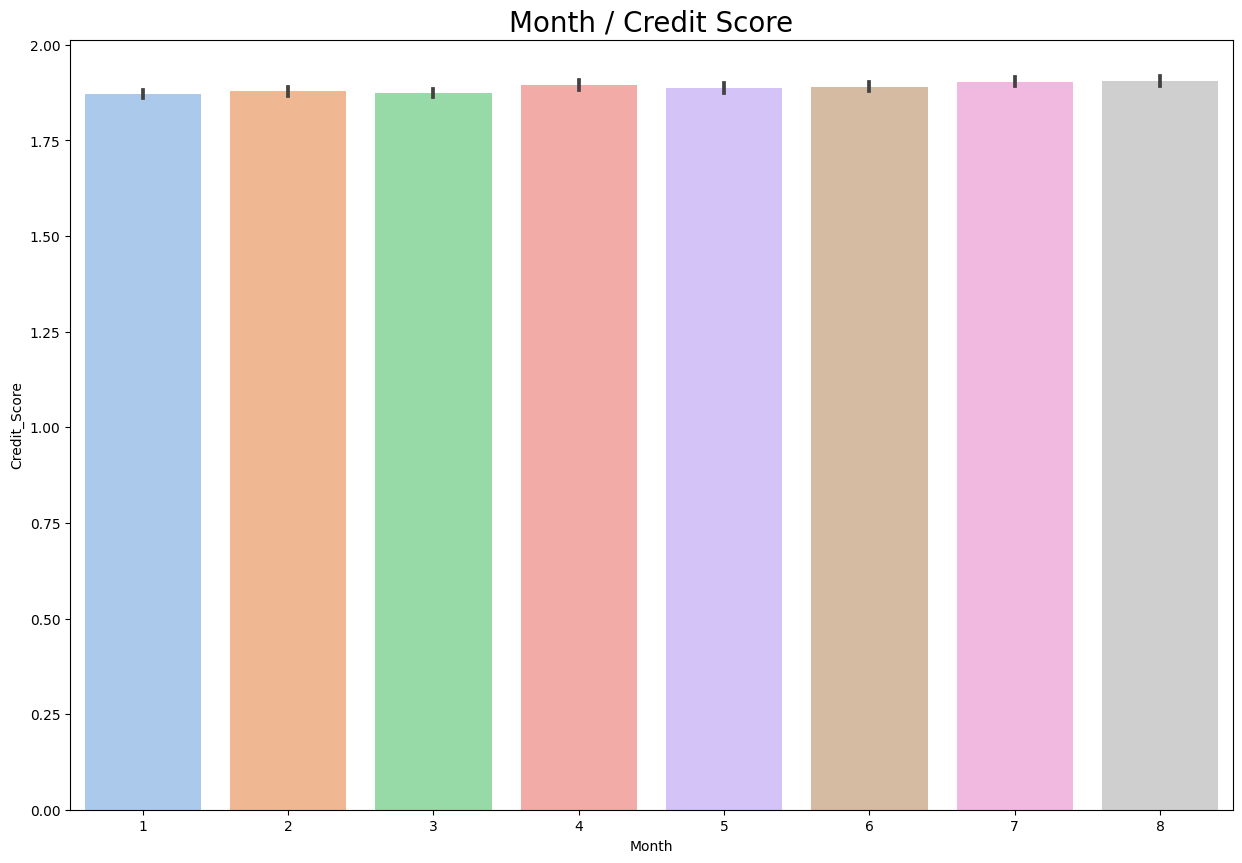

In [ ]:
plt.figure(figsize=(15,10))
sns.set_palette("pastel")
plt.title("Month / Credit Score", fontsize=20)
sns.barplot(x="Month", y="Credit_Score", data=df)
plt.show()

1. There is no big differnece when comparing Month values.


Make Age Range 10, 20, 30, 40, 50 and check out what happen.¶


In [ ]:
age_range = [i // 10 for i in df["Age"]]
df["Age_Range"] = age_range
df["Age_Range"].value_counts()

3.0    29080
2.0    28819
4.0    22396
1.0    11170
5.0     8535
Name: Age_Range, dtype: int64

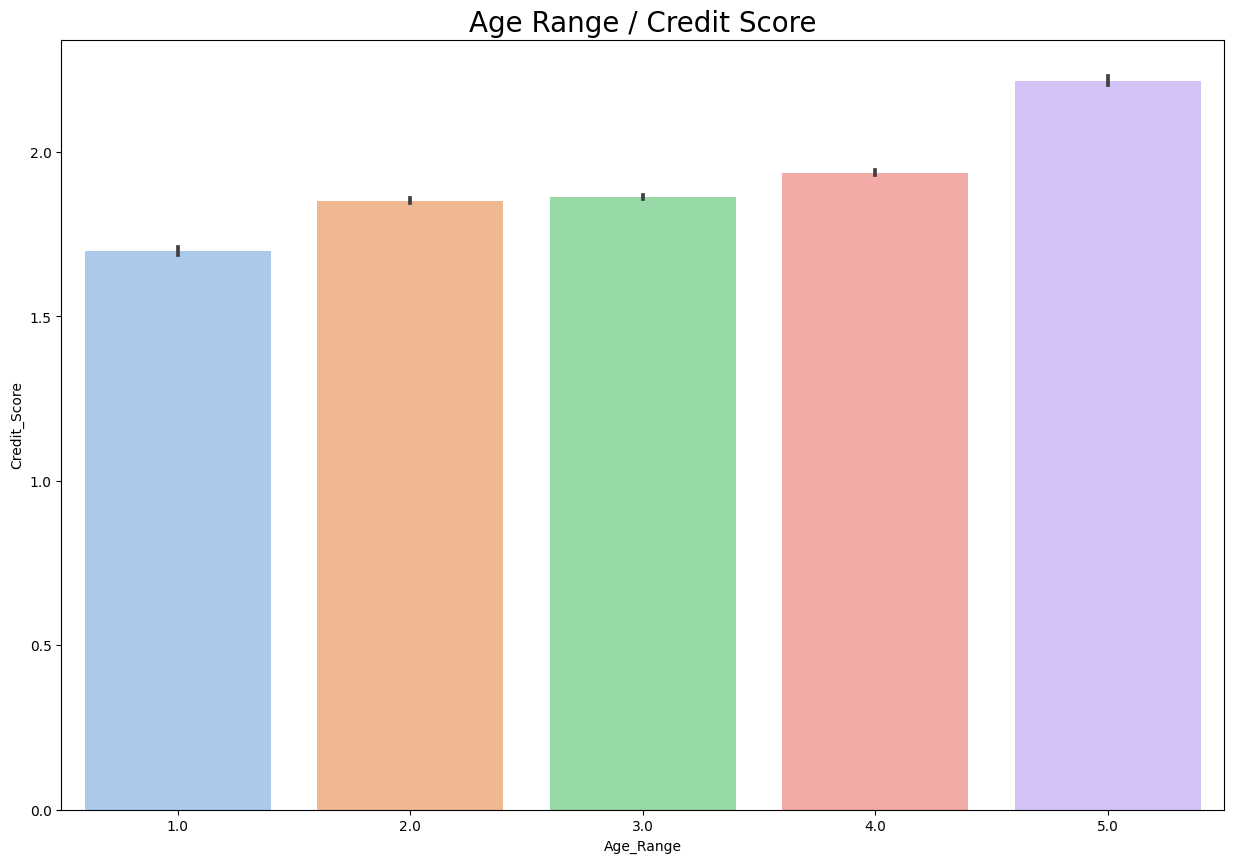

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x="Age_Range", y="Credit_Score", data=df)
plt.title("Age Range / Credit Score", fontsize=20)
plt.show()

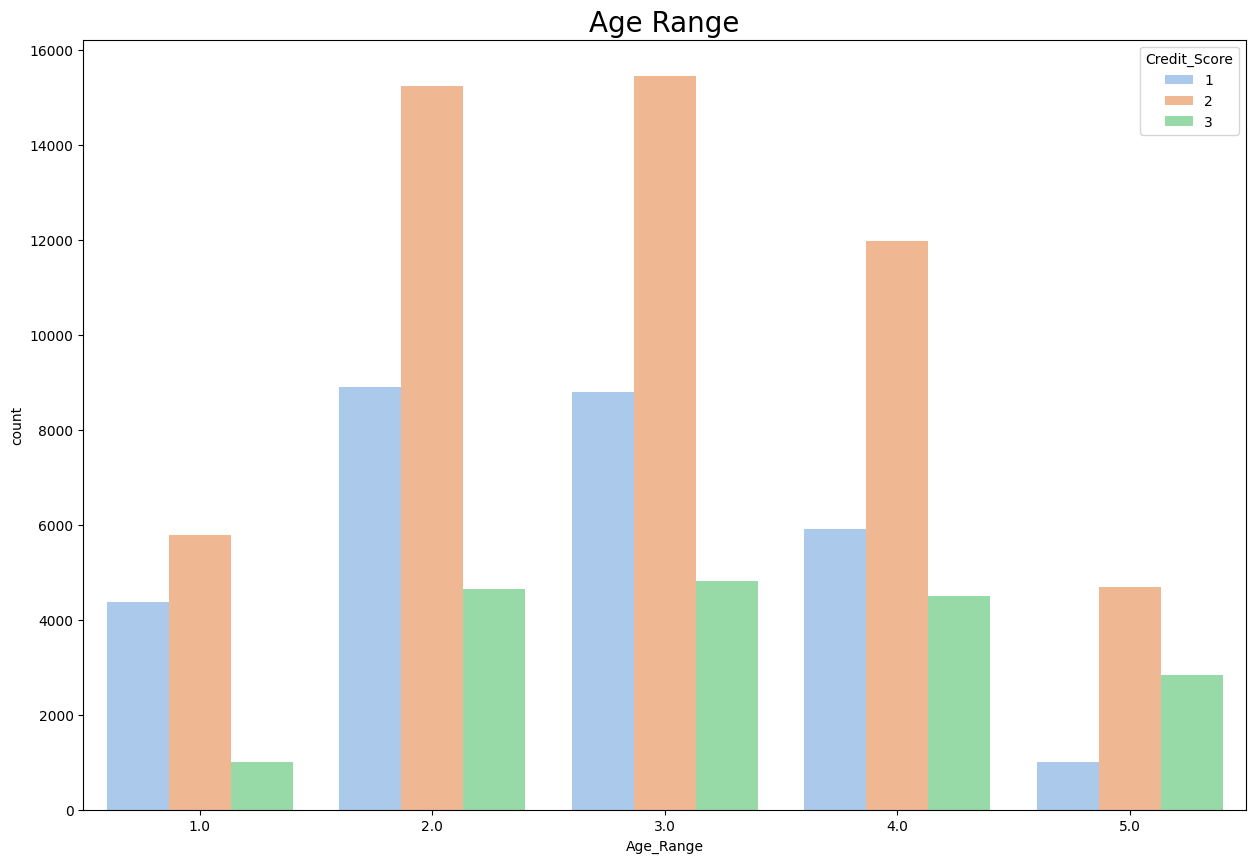

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x="Age_Range", hue="Credit_Score", data=df)
plt.title("Age Range", fontsize=20)
plt.show()

1. The order according to the number of people is 20s, 30s, 40s, 10s, and 50s.
2. The order according to the Credit Score is 50s, 40s, 30s, 20s, 10s.
3. Credit score of most of people is Standard.
4. There is no big difference between the number of people who got Good credit score in 20s, 30s, 40s.

In [ ]:
df["Occupation"].value_counts()

Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Scientist        6744
Accountant       6744
Developer        6720
Media_Manager    6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: Occupation, dtype: int64

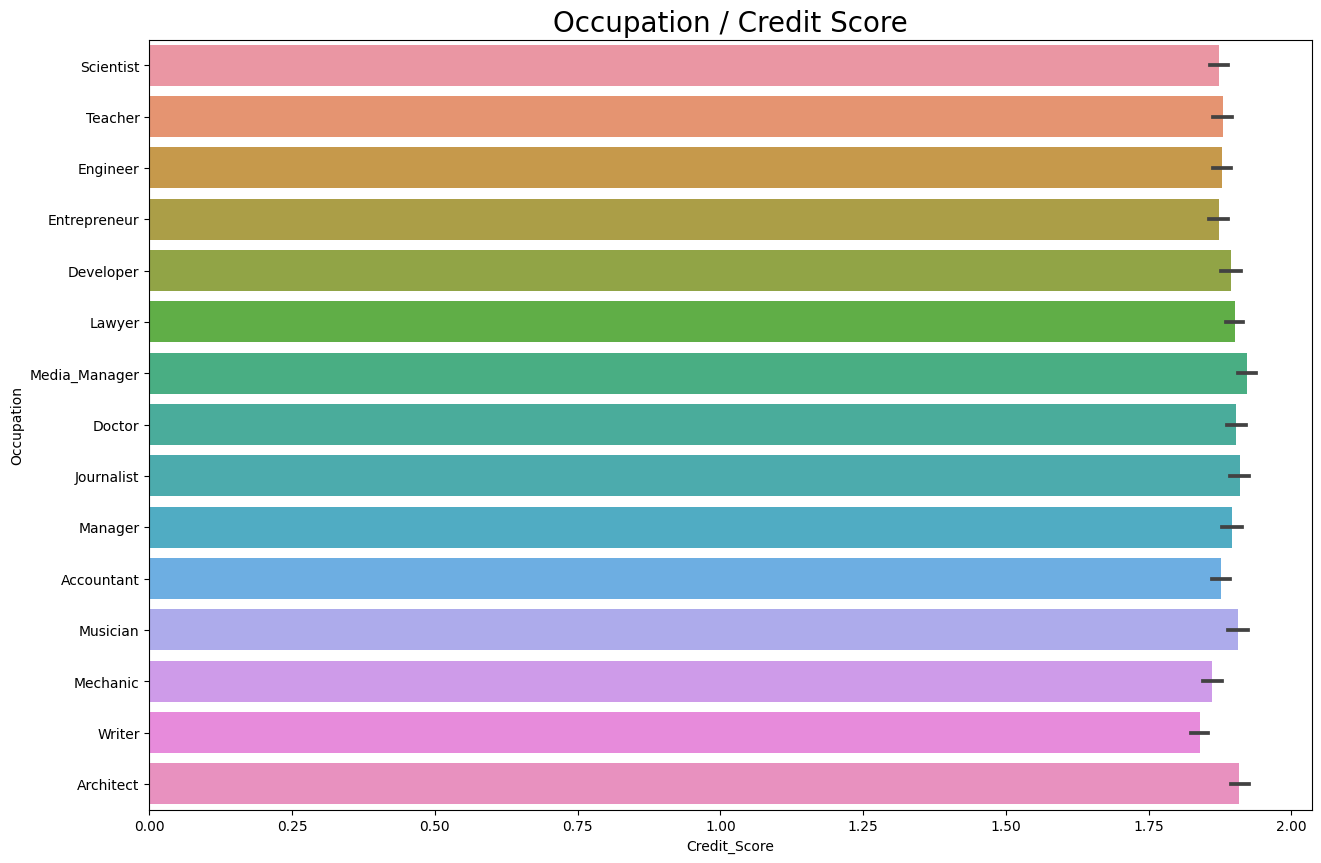

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x="Credit_Score", y="Occupation", data=df)
plt.title("Occupation / Credit Score", fontsize=20)
plt.show()

1. There are no big difference between occpupations.


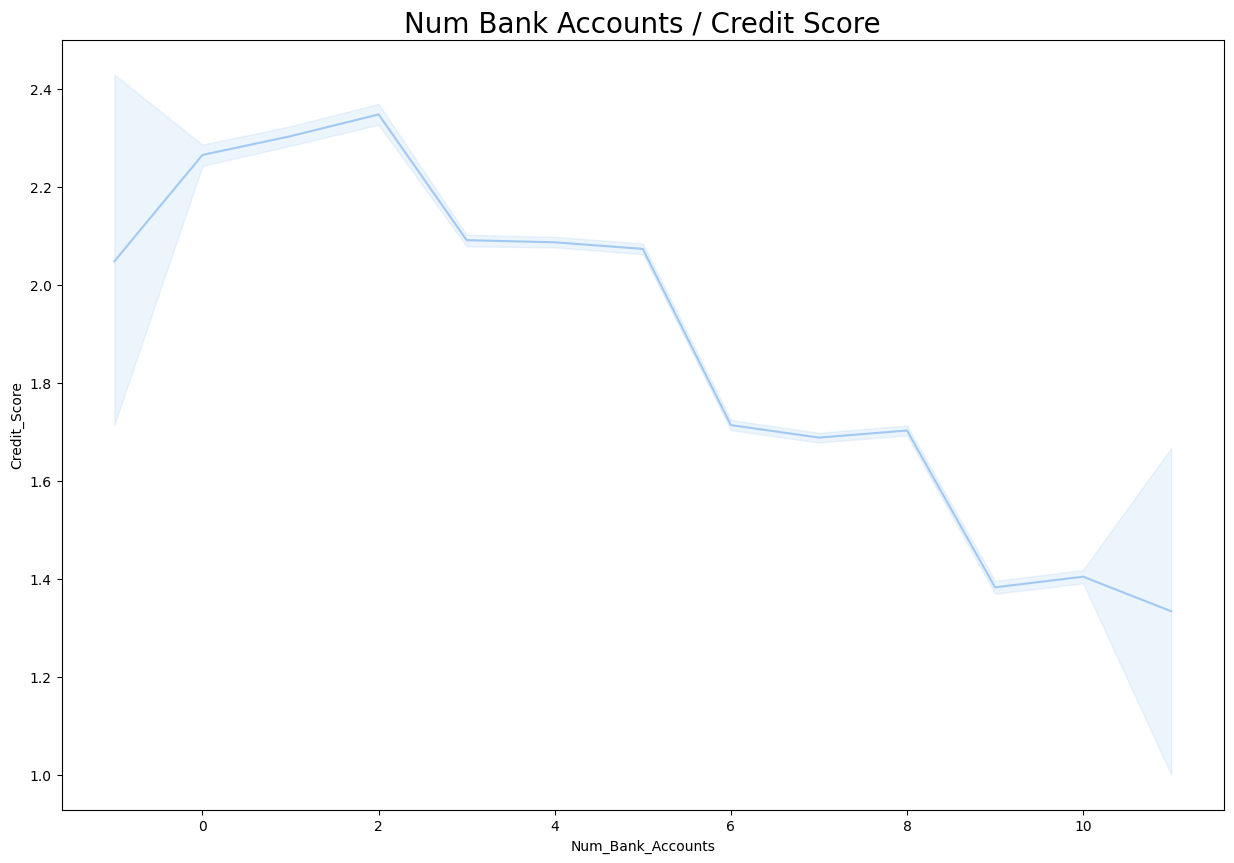

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Num_Bank_Accounts", y="Credit_Score", data=df)
plt.title("Num Bank Accounts / Credit Score", fontsize=20)
plt.show()

1. As the number of bank accounts increases, the credit score decreases.
2. The shape of the falling graph is closer to the shape of the staircase than to the straight line.

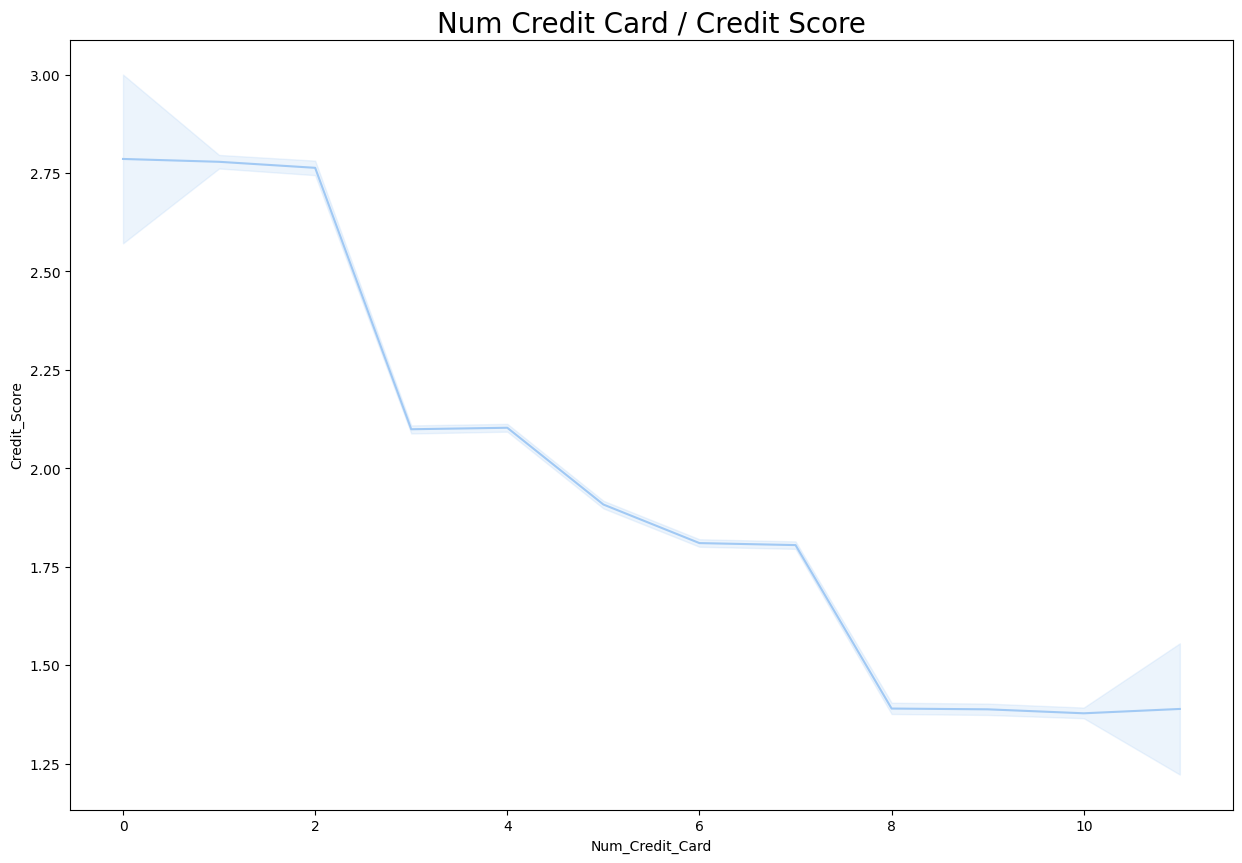

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Num_Credit_Card", y="Credit_Score", data=df)
plt.title("Num Credit Card / Credit Score", fontsize=20)
plt.show()

1. As the number of credit cards increases, the credit score decreases.
2. When the number of credit cards is 2-3 or 7-8, the credit score drops significantly.

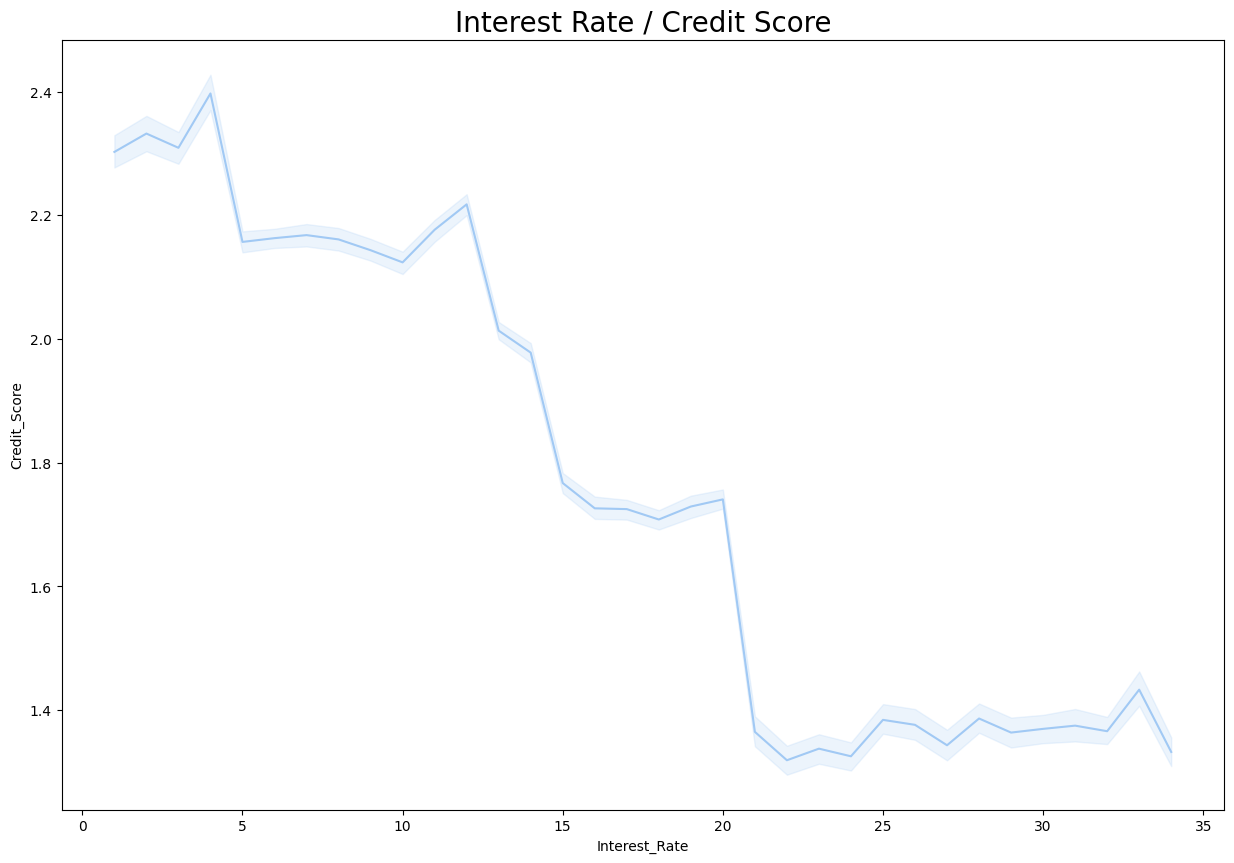

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Interest_Rate", y="Credit_Score", data=df)
plt.title("Interest Rate / Credit Score", fontsize=20)
plt.show()

1. When the interest rate is 8~9 and 20~21, the credit score decreases significantly.
2. As Interest Rate increases, the credit score decreases.

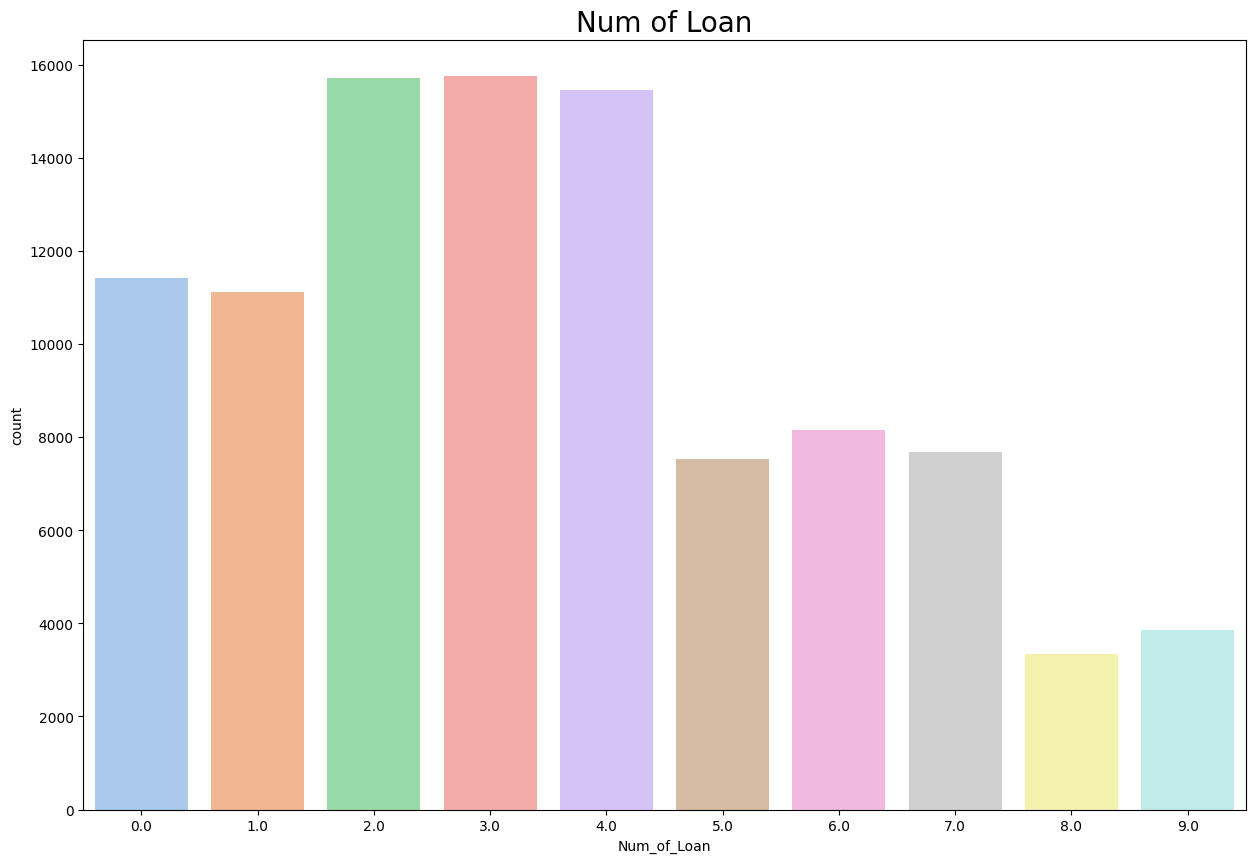

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(x="Num_of_Loan", data=df)
plt.title("Num of Loan", fontsize=20)
plt.show()

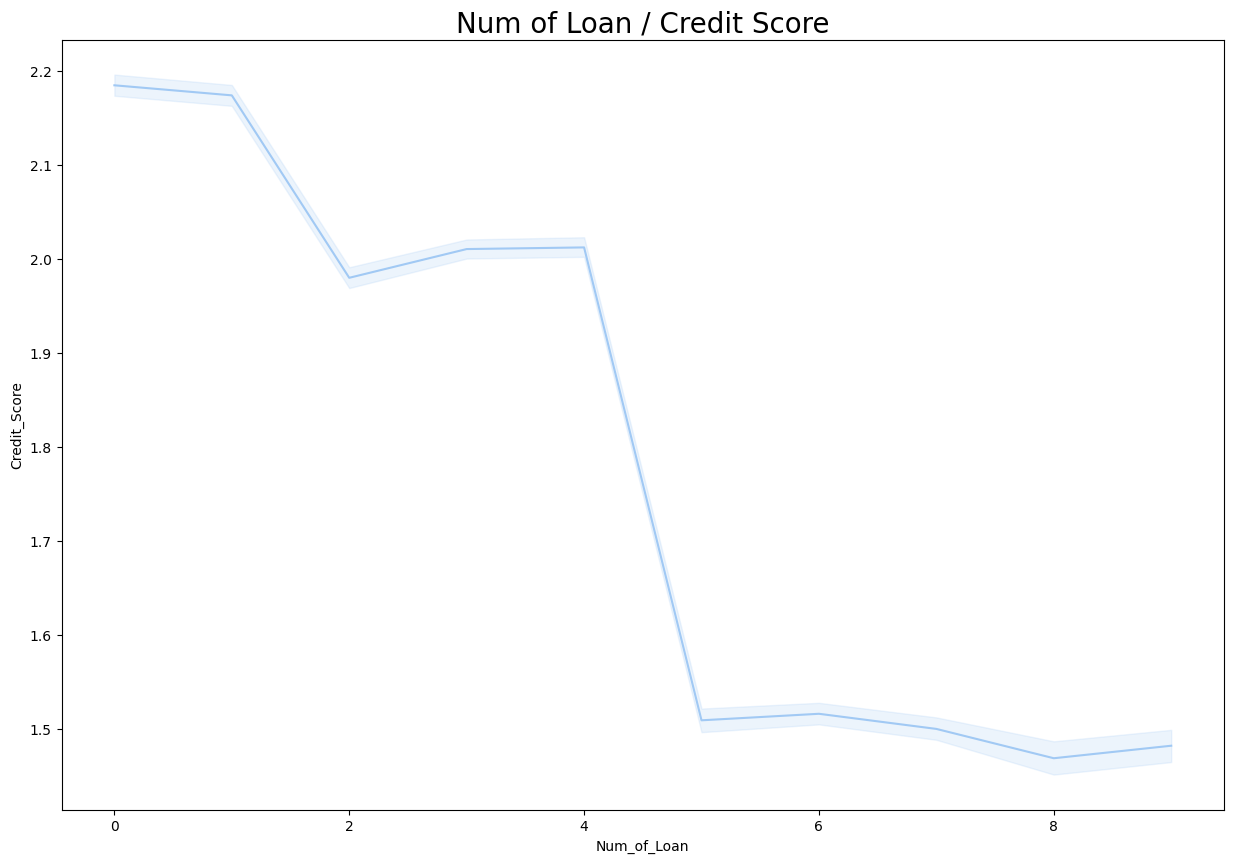

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Num_of_Loan", y="Credit_Score", data=df)
plt.title("Num of Loan / Credit Score", fontsize=20)
plt.show()

1. As the number of loans increases, the credit score decreases.
2. The number of people who took out loans is the highest in number 2, 3, and 4. And you can see that there are even people who received numbers 8 and 9.
3. It can be seen that the credit score is falling sharply from the number of loans taken from 1 to 2, 4 to 5. In particular, a really significant decline can be seen in 4 to 5.

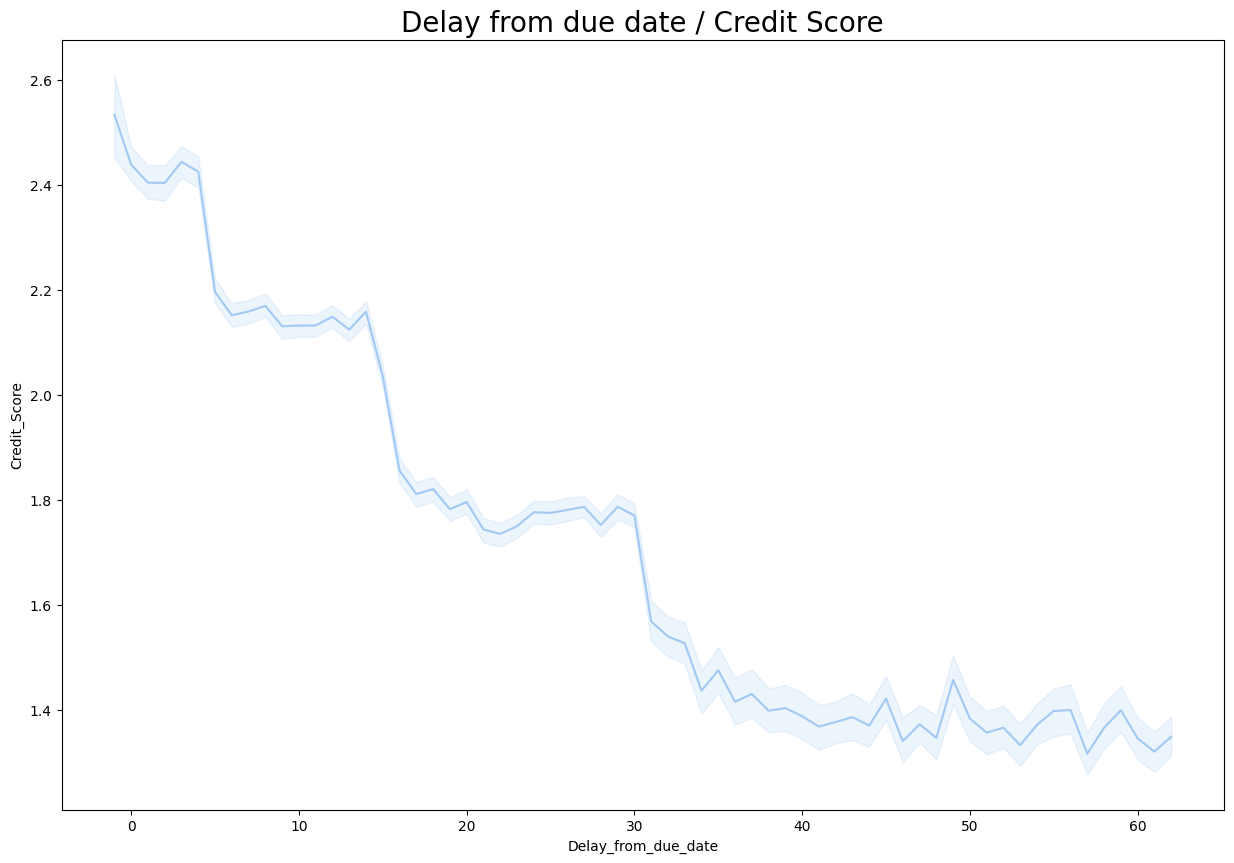

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Delay_from_due_date", y="Credit_Score", data=df)
plt.title("Delay from due date / Credit Score", fontsize=20)
plt.show()

1. As delay from due date increases, the credit score decreases.


<ipython-input-56-200a680ad205>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Num_of_Delayed_Payment"])


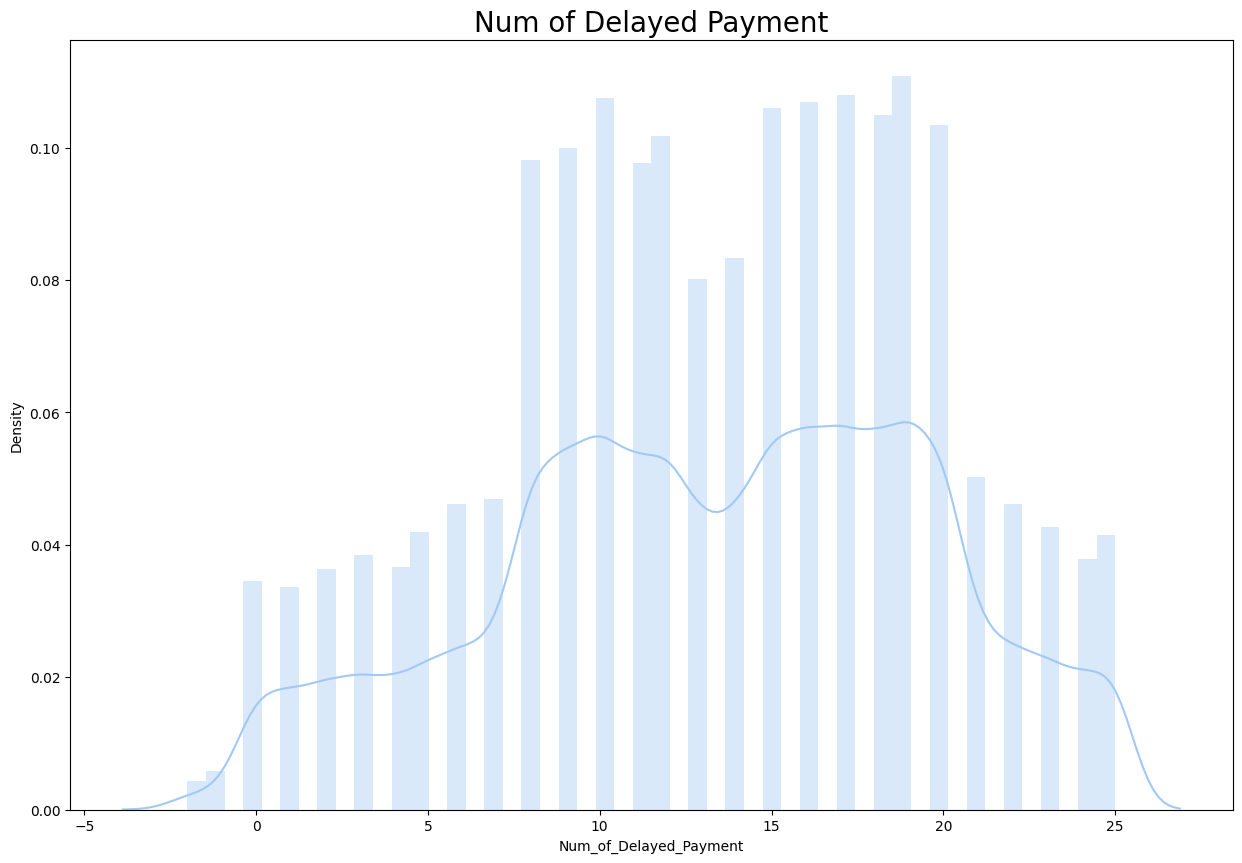

In [ ]:
plt.figure(figsize=(15,10))
sns.distplot(df["Num_of_Delayed_Payment"])
plt.title("Num of Delayed Payment", fontsize=20)
plt.show()

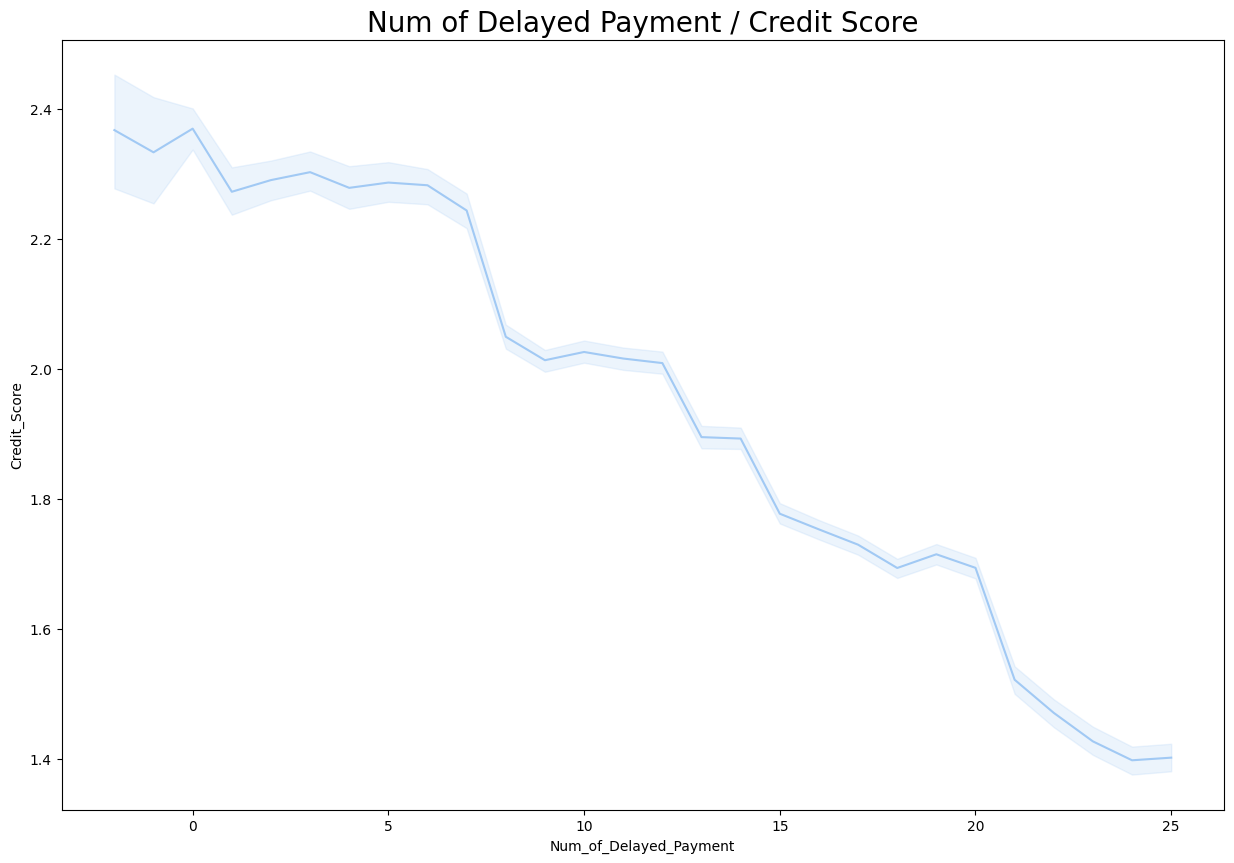

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Num_of_Delayed_Payment", y="Credit_Score", data=df)
plt.title("Num of Delayed Payment / Credit Score", fontsize=20)
plt.show()

1. Most people have yet to pay 8 to 20 kinds of money.
2. The higher the number of overdue payments, the lower the credit score, which is almost straight.

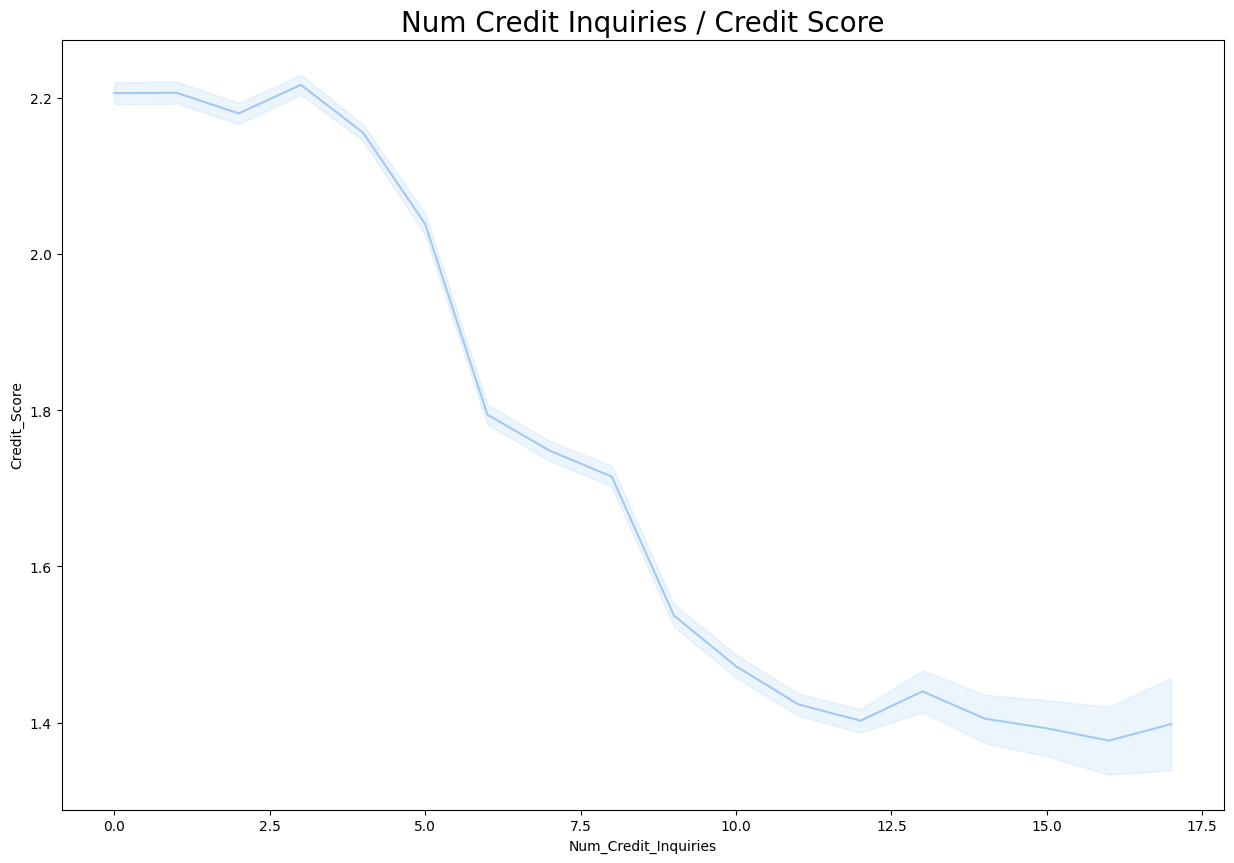

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(x="Num_Credit_Inquiries", y="Credit_Score", data=df)
plt.title("Num Credit Inquiries / Credit Score", fontsize=20)
plt.show()

1. The more Num Credit Inquires increase, the lower the credit score.
2. Num Credit Inquires shows a sharp drop in credit scores between 2 and 12.

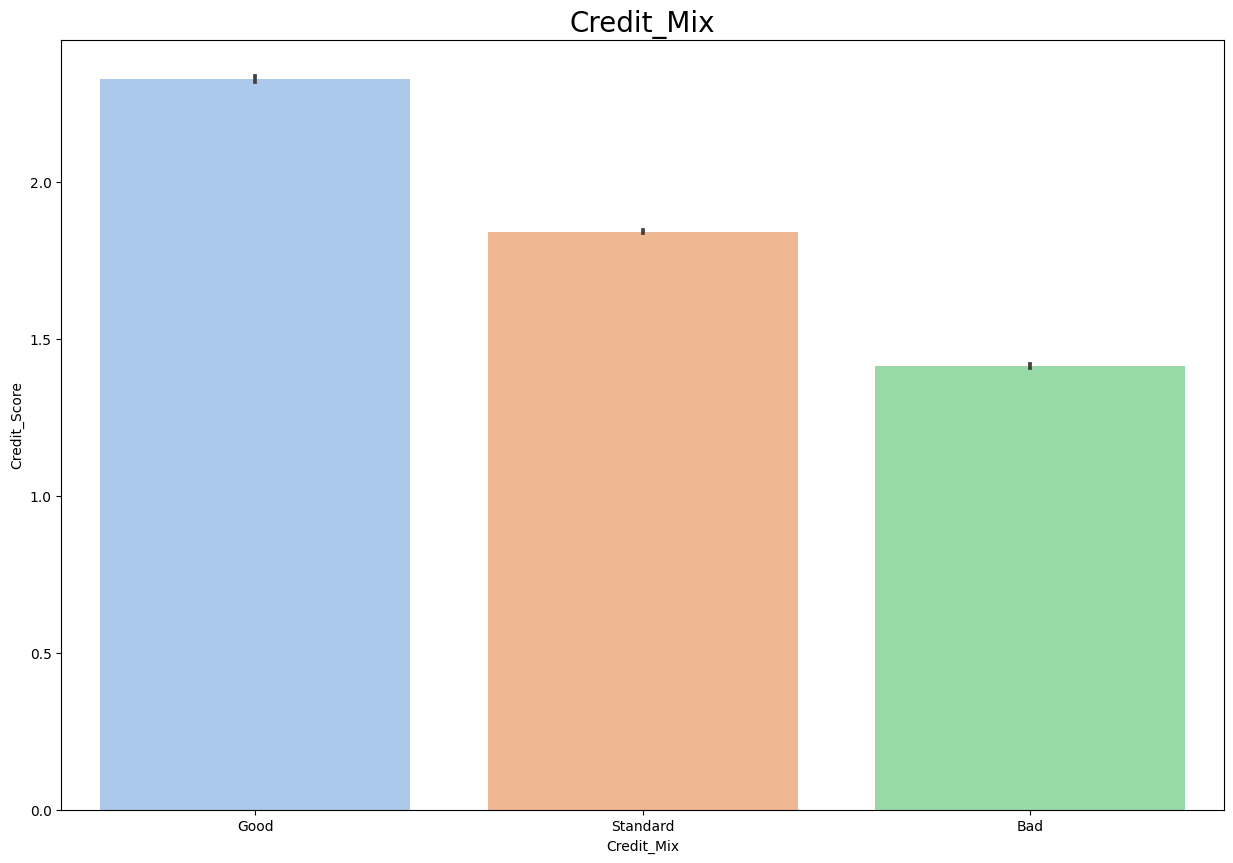

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x="Credit_Mix", y="Credit_Score", data=df)
plt.title("Credit_Mix", fontsize=20)
plt.show()

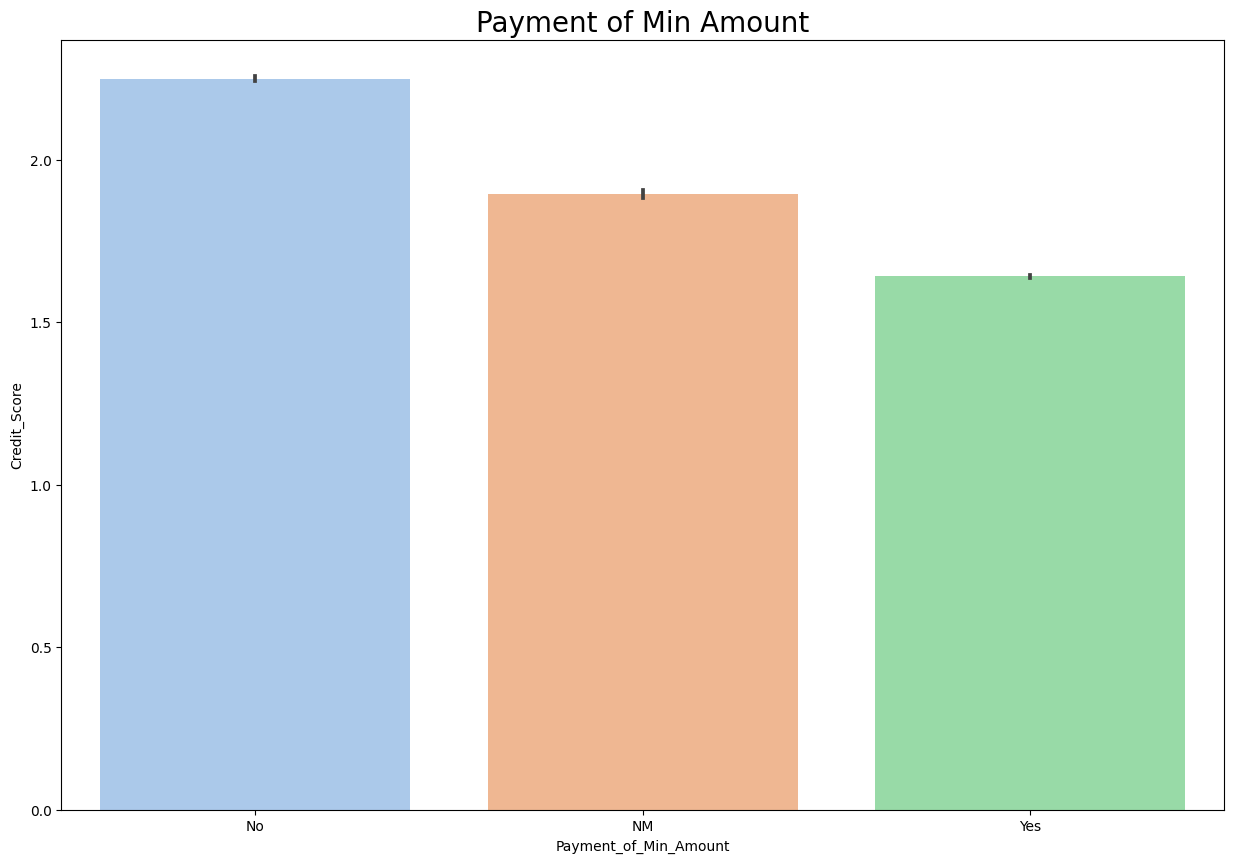

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x="Payment_of_Min_Amount", y="Credit_Score", data=df)
plt.title("Payment of Min Amount", fontsize=20)
plt.show()

1. Credit Mix, Payment of Min Amount, has a direct relationship with the credit score.


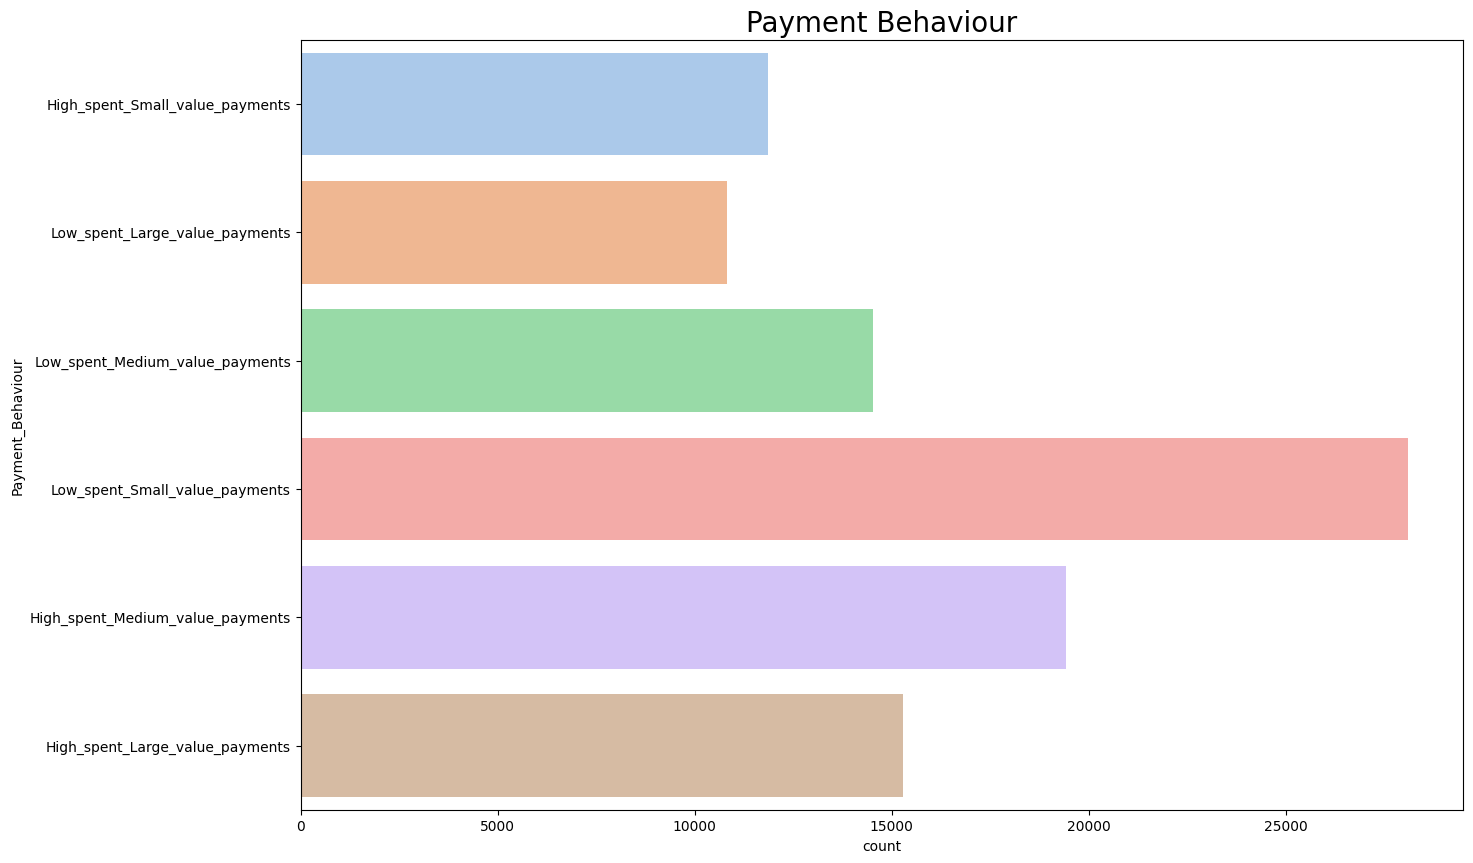

In [ ]:
plt.figure(figsize=(15,10))
sns.countplot(y="Payment_Behaviour", data=df)
plt.title("Payment Behaviour", fontsize=20)
plt.show()

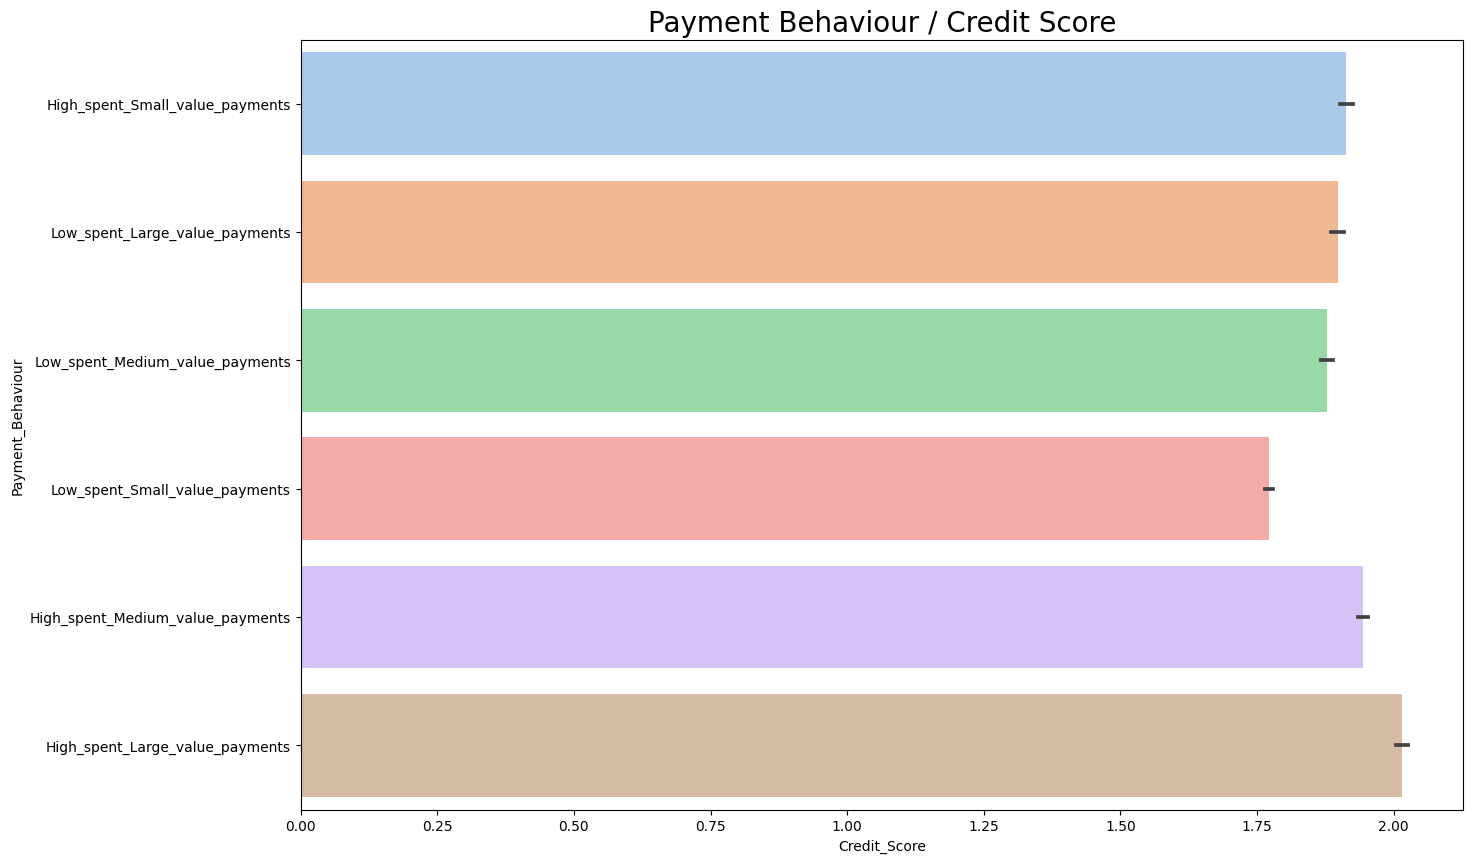

In [ ]:
plt.figure(figsize=(15,10))
sns.barplot(x="Credit_Score", y="Payment_Behaviour", data=df)
plt.title("Payment Behaviour / Credit Score", fontsize=20)
plt.show()

1. The number of people in the Low_spent_Small_value_payments group is the highest. But their credit scores are the lowest.
2. People in the High_spent_Large_value_payments group have the best credit scores.

In [ ]:
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Age_Range
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,26.822620,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,3,2.0
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,31.944960,266.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,3,2.0
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,28.609352,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,3,2.0
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,31.377862,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,3,2.0
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,24.797347,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,502.38,34.663572,378.0,No,35.104023,60.971333,High_spent_Large_value_payments,479.866228,1,2.0
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,502.38,40.565631,379.0,No,35.104023,54.185950,High_spent_Medium_value_payments,496.651610,1,2.0
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,1,2.0
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,502.38,33.638208,381.0,No,35.104023,251.672582,Low_spent_Large_value_payments,319.164979,2,2.0


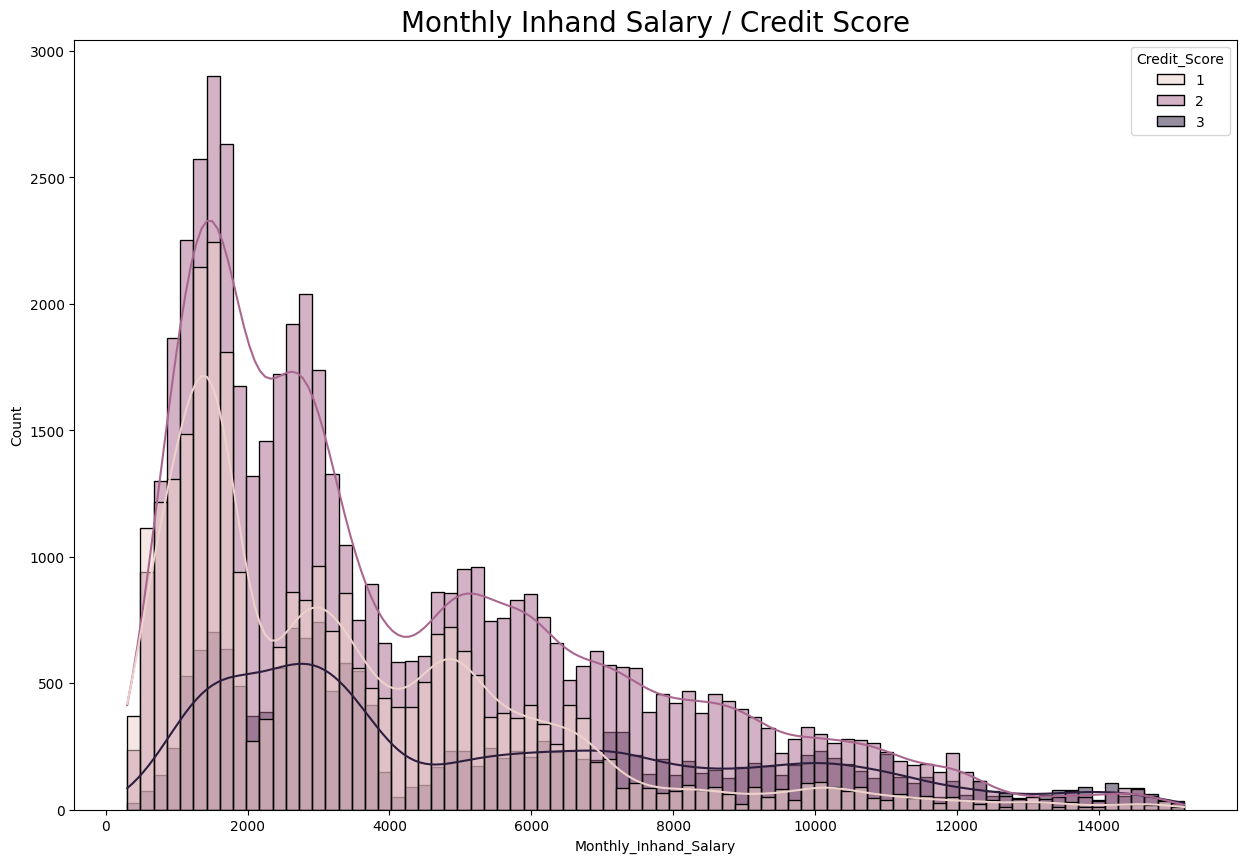

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Monthly_Inhand_Salary", hue="Credit_Score", kde= True, data=df)
plt.title("Monthly Inhand Salary / Credit Score", fontsize=20)
plt.show()

1. People with good credit scores have a higher distribution of Monthly Inhand Salaries than people with Standard or Poor.

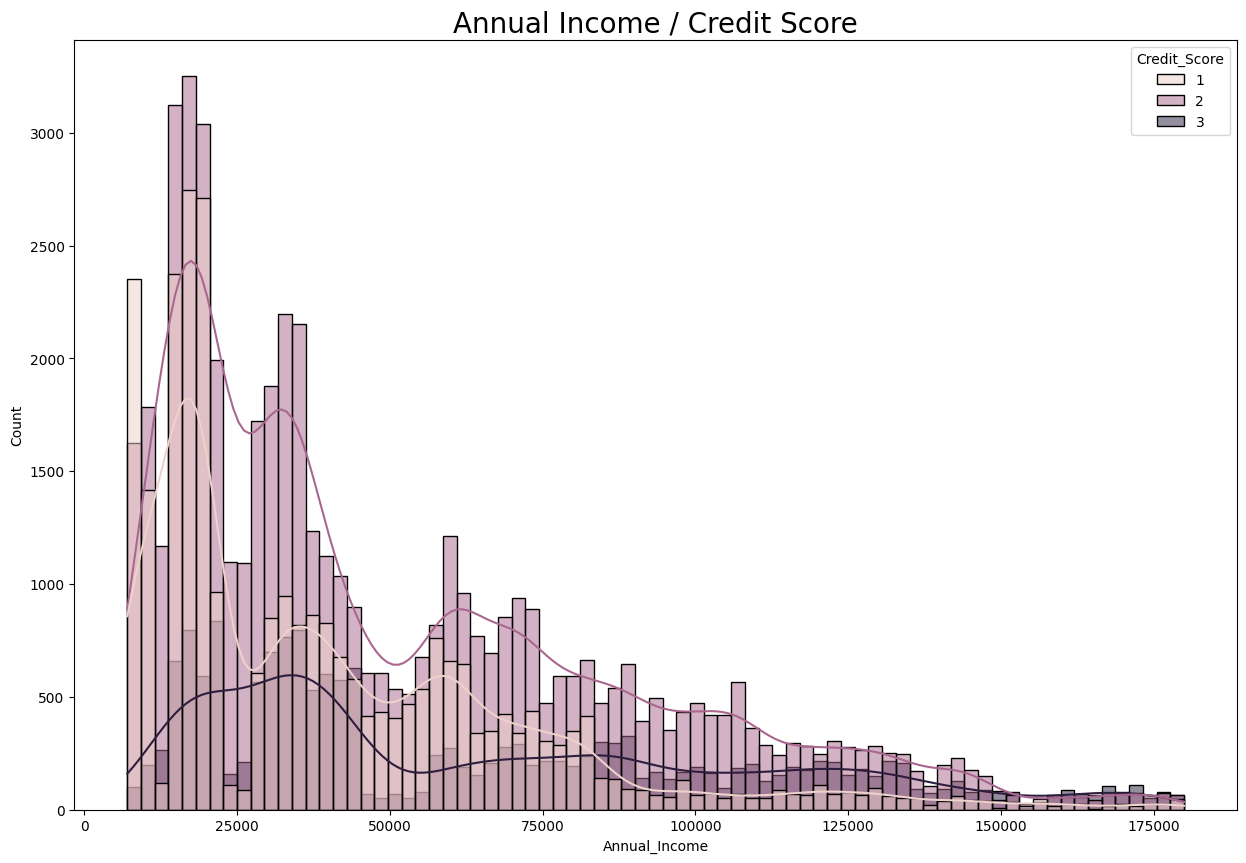

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Annual_Income", hue="Credit_Score", kde= True, data=df)
plt.title("Annual Income / Credit Score", fontsize=20)
plt.show()

1. People with good credit scores have a higher distribution of Annual Income than people with Standard or Poor.
2. If you look at the graph of Annual Income rather than the graph of Monthly Inhand Salary, you can see the difference between the three groups more clearly.

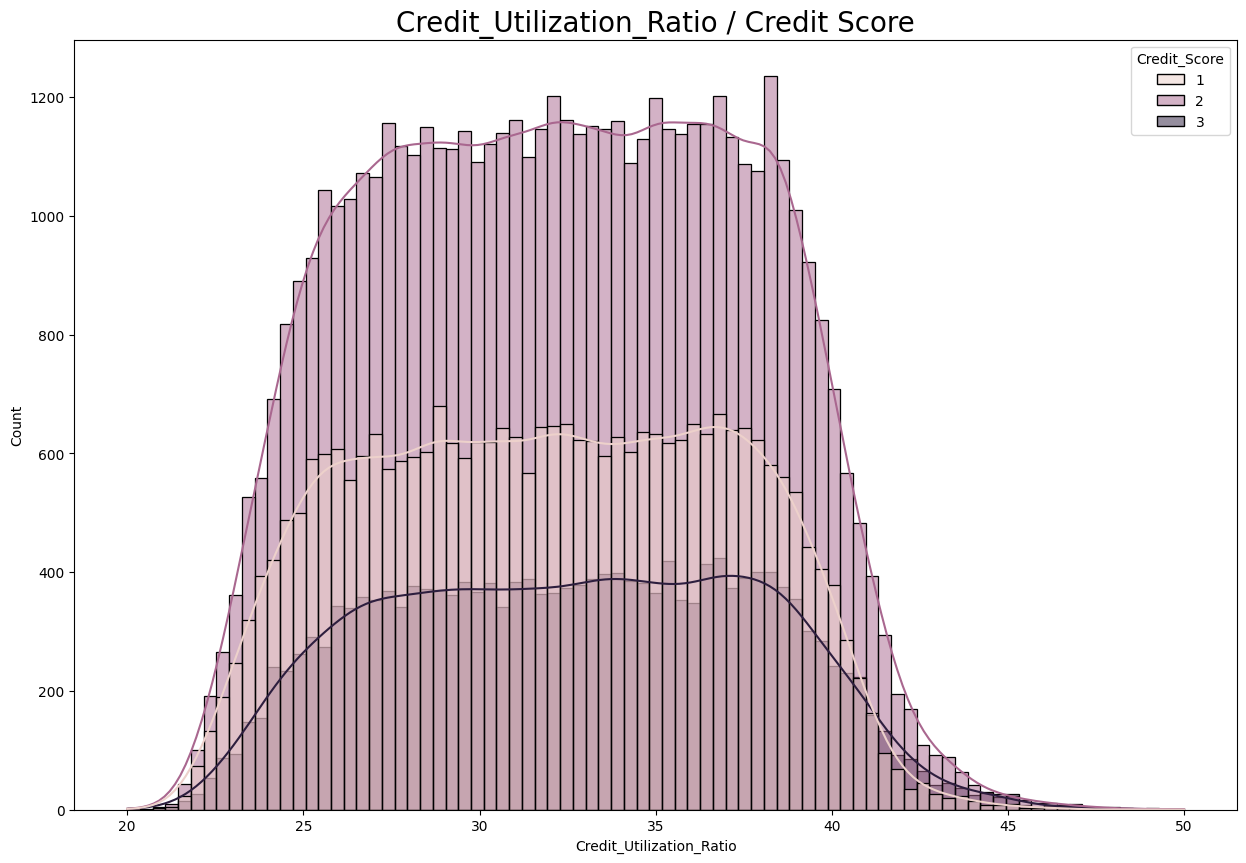

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Credit_Utilization_Ratio", hue="Credit_Score", kde= True, data=df)
plt.title("Credit_Utilization_Ratio / Credit Score", fontsize=20)
plt.show()

1. There is only a difference in the number of people, but there is no big difference between the three groups.

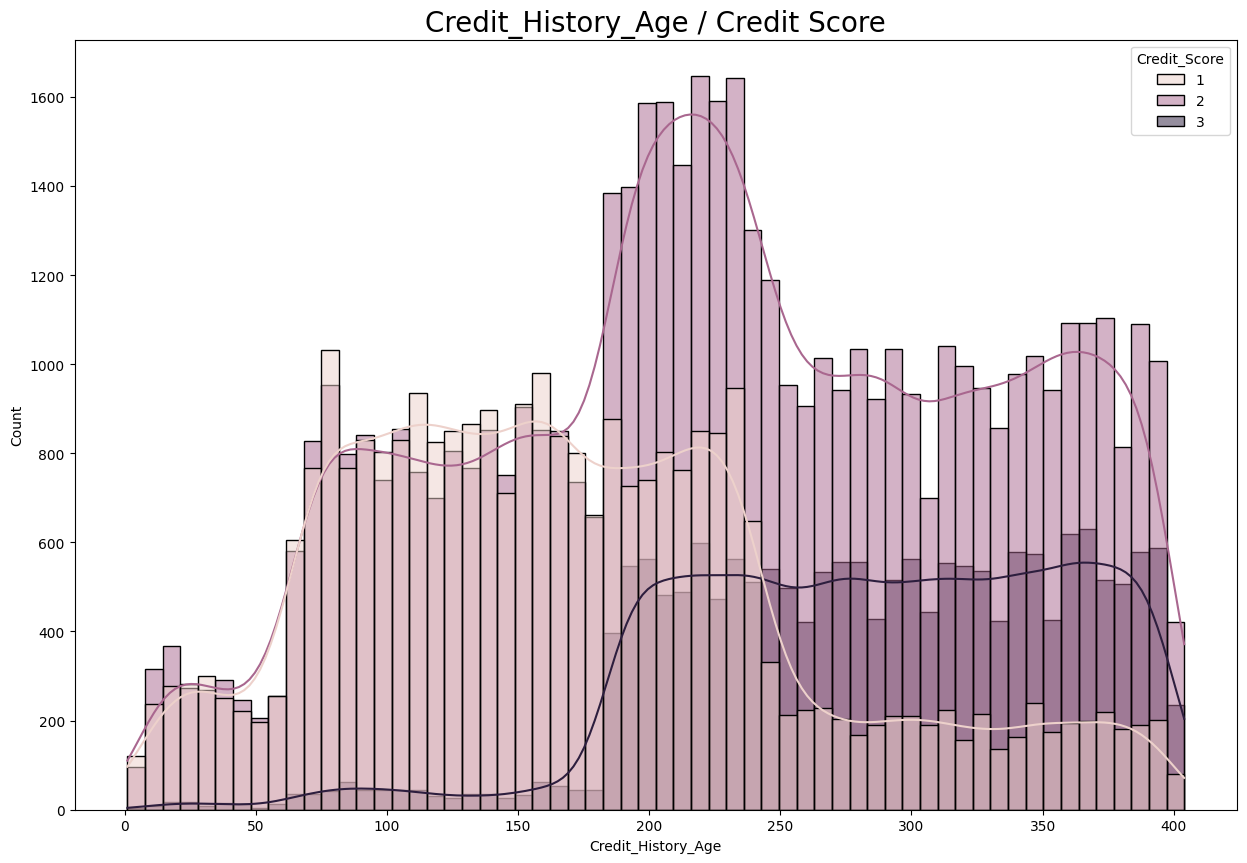

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Credit_History_Age", hue="Credit_Score", kde= True, data=df)
plt.title("Credit_History_Age / Credit Score", fontsize=20)
plt.show()

1. People belonging to Poor are widely distributed on the side with low Credit History Age values.
2. Those who belong to Standard have a higher Credit History Age value than those who belong to Poor. Most of the people who belong to Good are widely distributed at high prices.

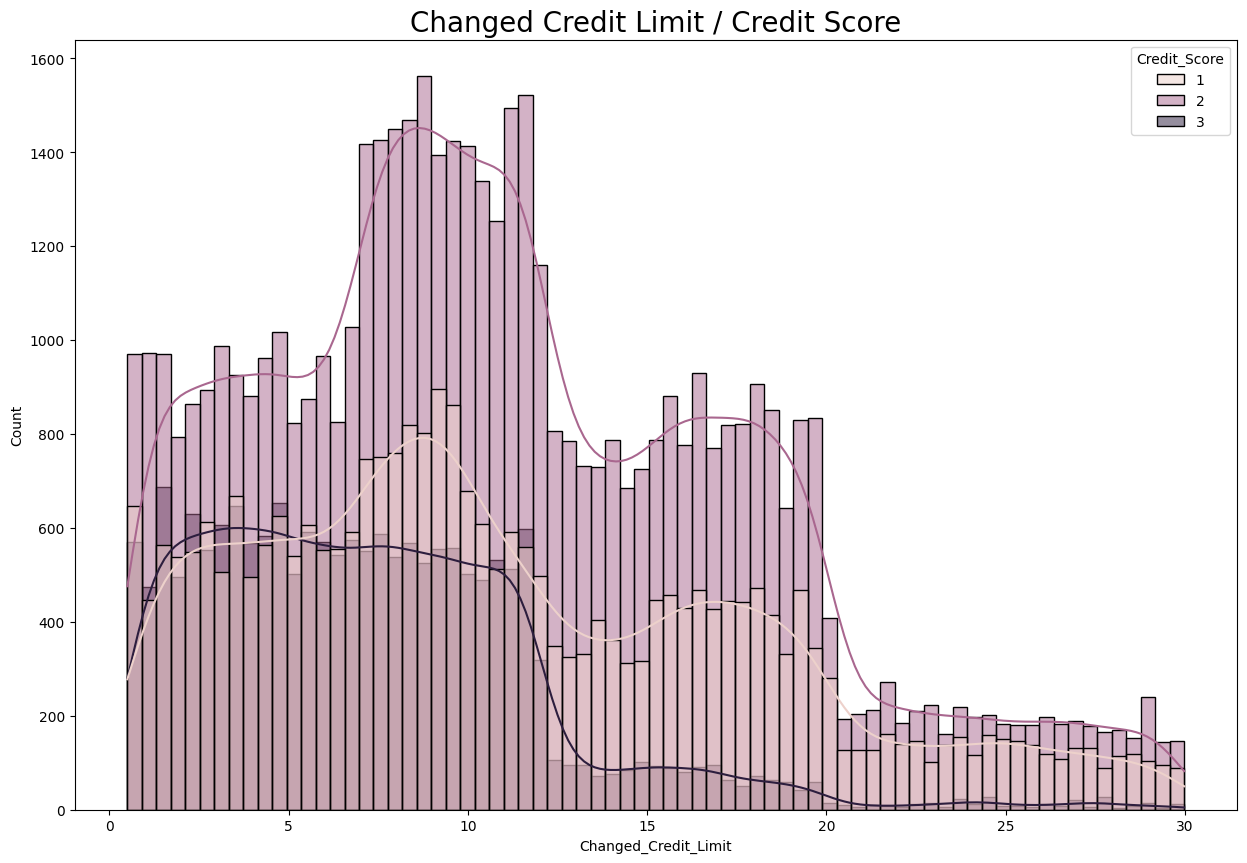

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Changed_Credit_Limit", hue="Credit_Score", kde= True, data=df)
plt.title("Changed Credit Limit / Credit Score", fontsize=20)
plt.show()

1. Those with a Good Credit Score changed their Credit Limit less than those with Standard or Poor.

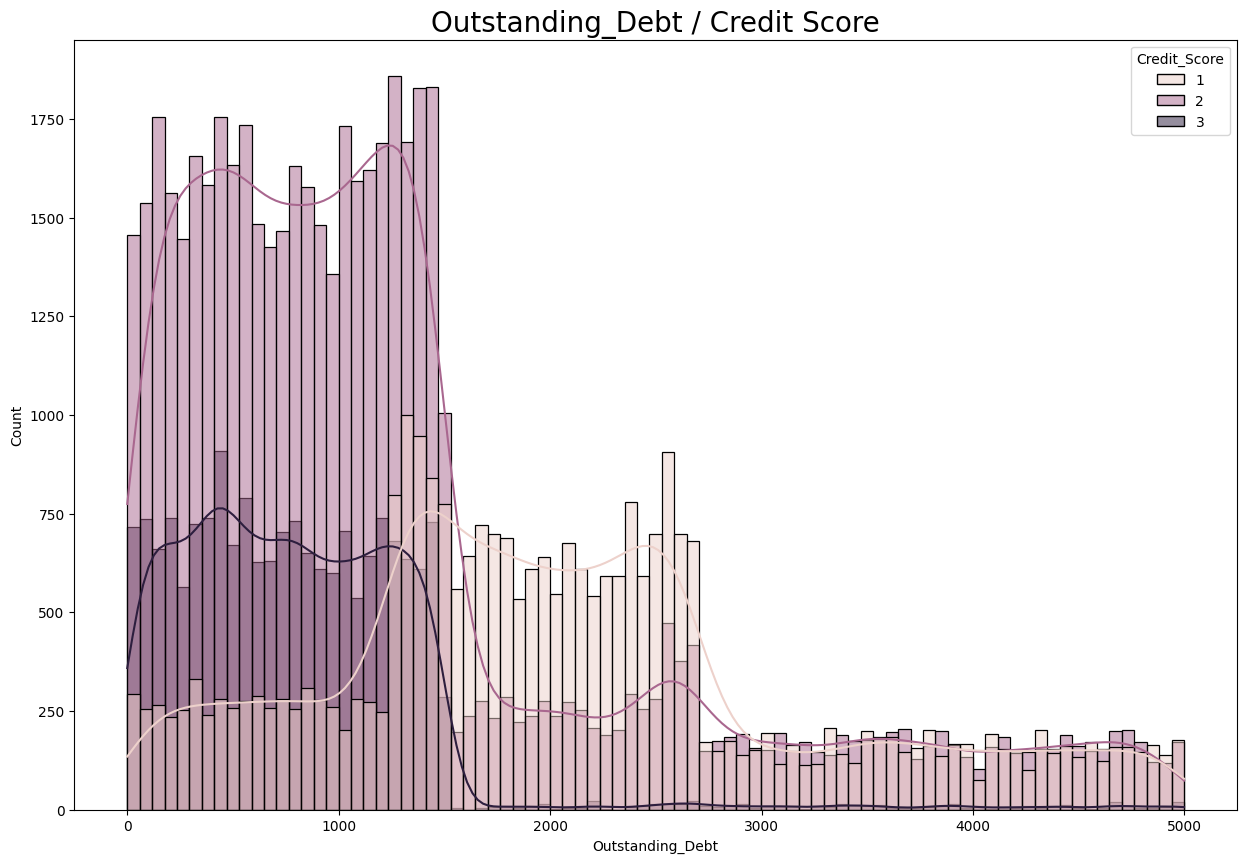

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(x="Outstanding_Debt", hue="Credit_Score", kde= True, data=df)
plt.title("Outstanding_Debt / Credit Score", fontsize=20)
plt.show()

1. People with Credit Score as Poor are more distributed where Outstanding Debt values are higher than those who belong to Standard or Poor.
2. Most people with a Good Credit Score do not have more than 1500 Outstanding Debts.

# Modeling (LightGBM)

In [3]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
params = {
    "n_estimators": [100, 500, 1000],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "lambda_l1": [0, 10, 20, 30, 50],
    "lambda_l2": [0, 10, 20, 30, 50],
    "max_depth": [5, 10, 15, 20],
    "subsample": [0.6, 0.8, 1]
}

In [ ]:
model_pre = lgb.LGBMClassifier()
model = RandomizedSearchCV(model_pre, param_distributions=params, n_jobs=-1, n_iter=30)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
data = pd.get_dummies(df, columns=["Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"], drop_first=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   ID                                                  100000 non-null  int64  
 1   Customer_ID                                         100000 non-null  int64  
 2   Month                                               100000 non-null  int64  
 3   Name                                                100000 non-null  object 
 4   Age                                                 100000 non-null  float64
 5   SSN                                                 100000 non-null  float64
 6   Annual_Income                                       100000 non-null  float64
 7   Monthly_Inhand_Salary                               100000 non-null  float64
 8   Num_Bank_Accounts                                   100000 non-nu

In [ ]:
X = data.drop(["ID", "Customer_ID", "Name", "SSN", "Type_of_Loan", "Credit_Score"], axis=1)
y = data["Credit_Score"]

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40)

search = model.fit(X_train, y_train)

print(search.best_score_)
print(search.best_params_)

X shape:  (100000, 28)
y shape:  (100000,)
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
0.8167500000000001
{'subsample': 0.6, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.3, 'lambda_l2': 10, 'lambda_l1': 0}


In [ ]:
# Save results
cv_results = pd.DataFrame(search.cv_results_)
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)
cv_results.to_csv("RandomSearch_CV_LGBM.csv")

In [ ]:
# Load results
cv_results = pd.read_csv("RandomSearch_CV_LGBM.csv")

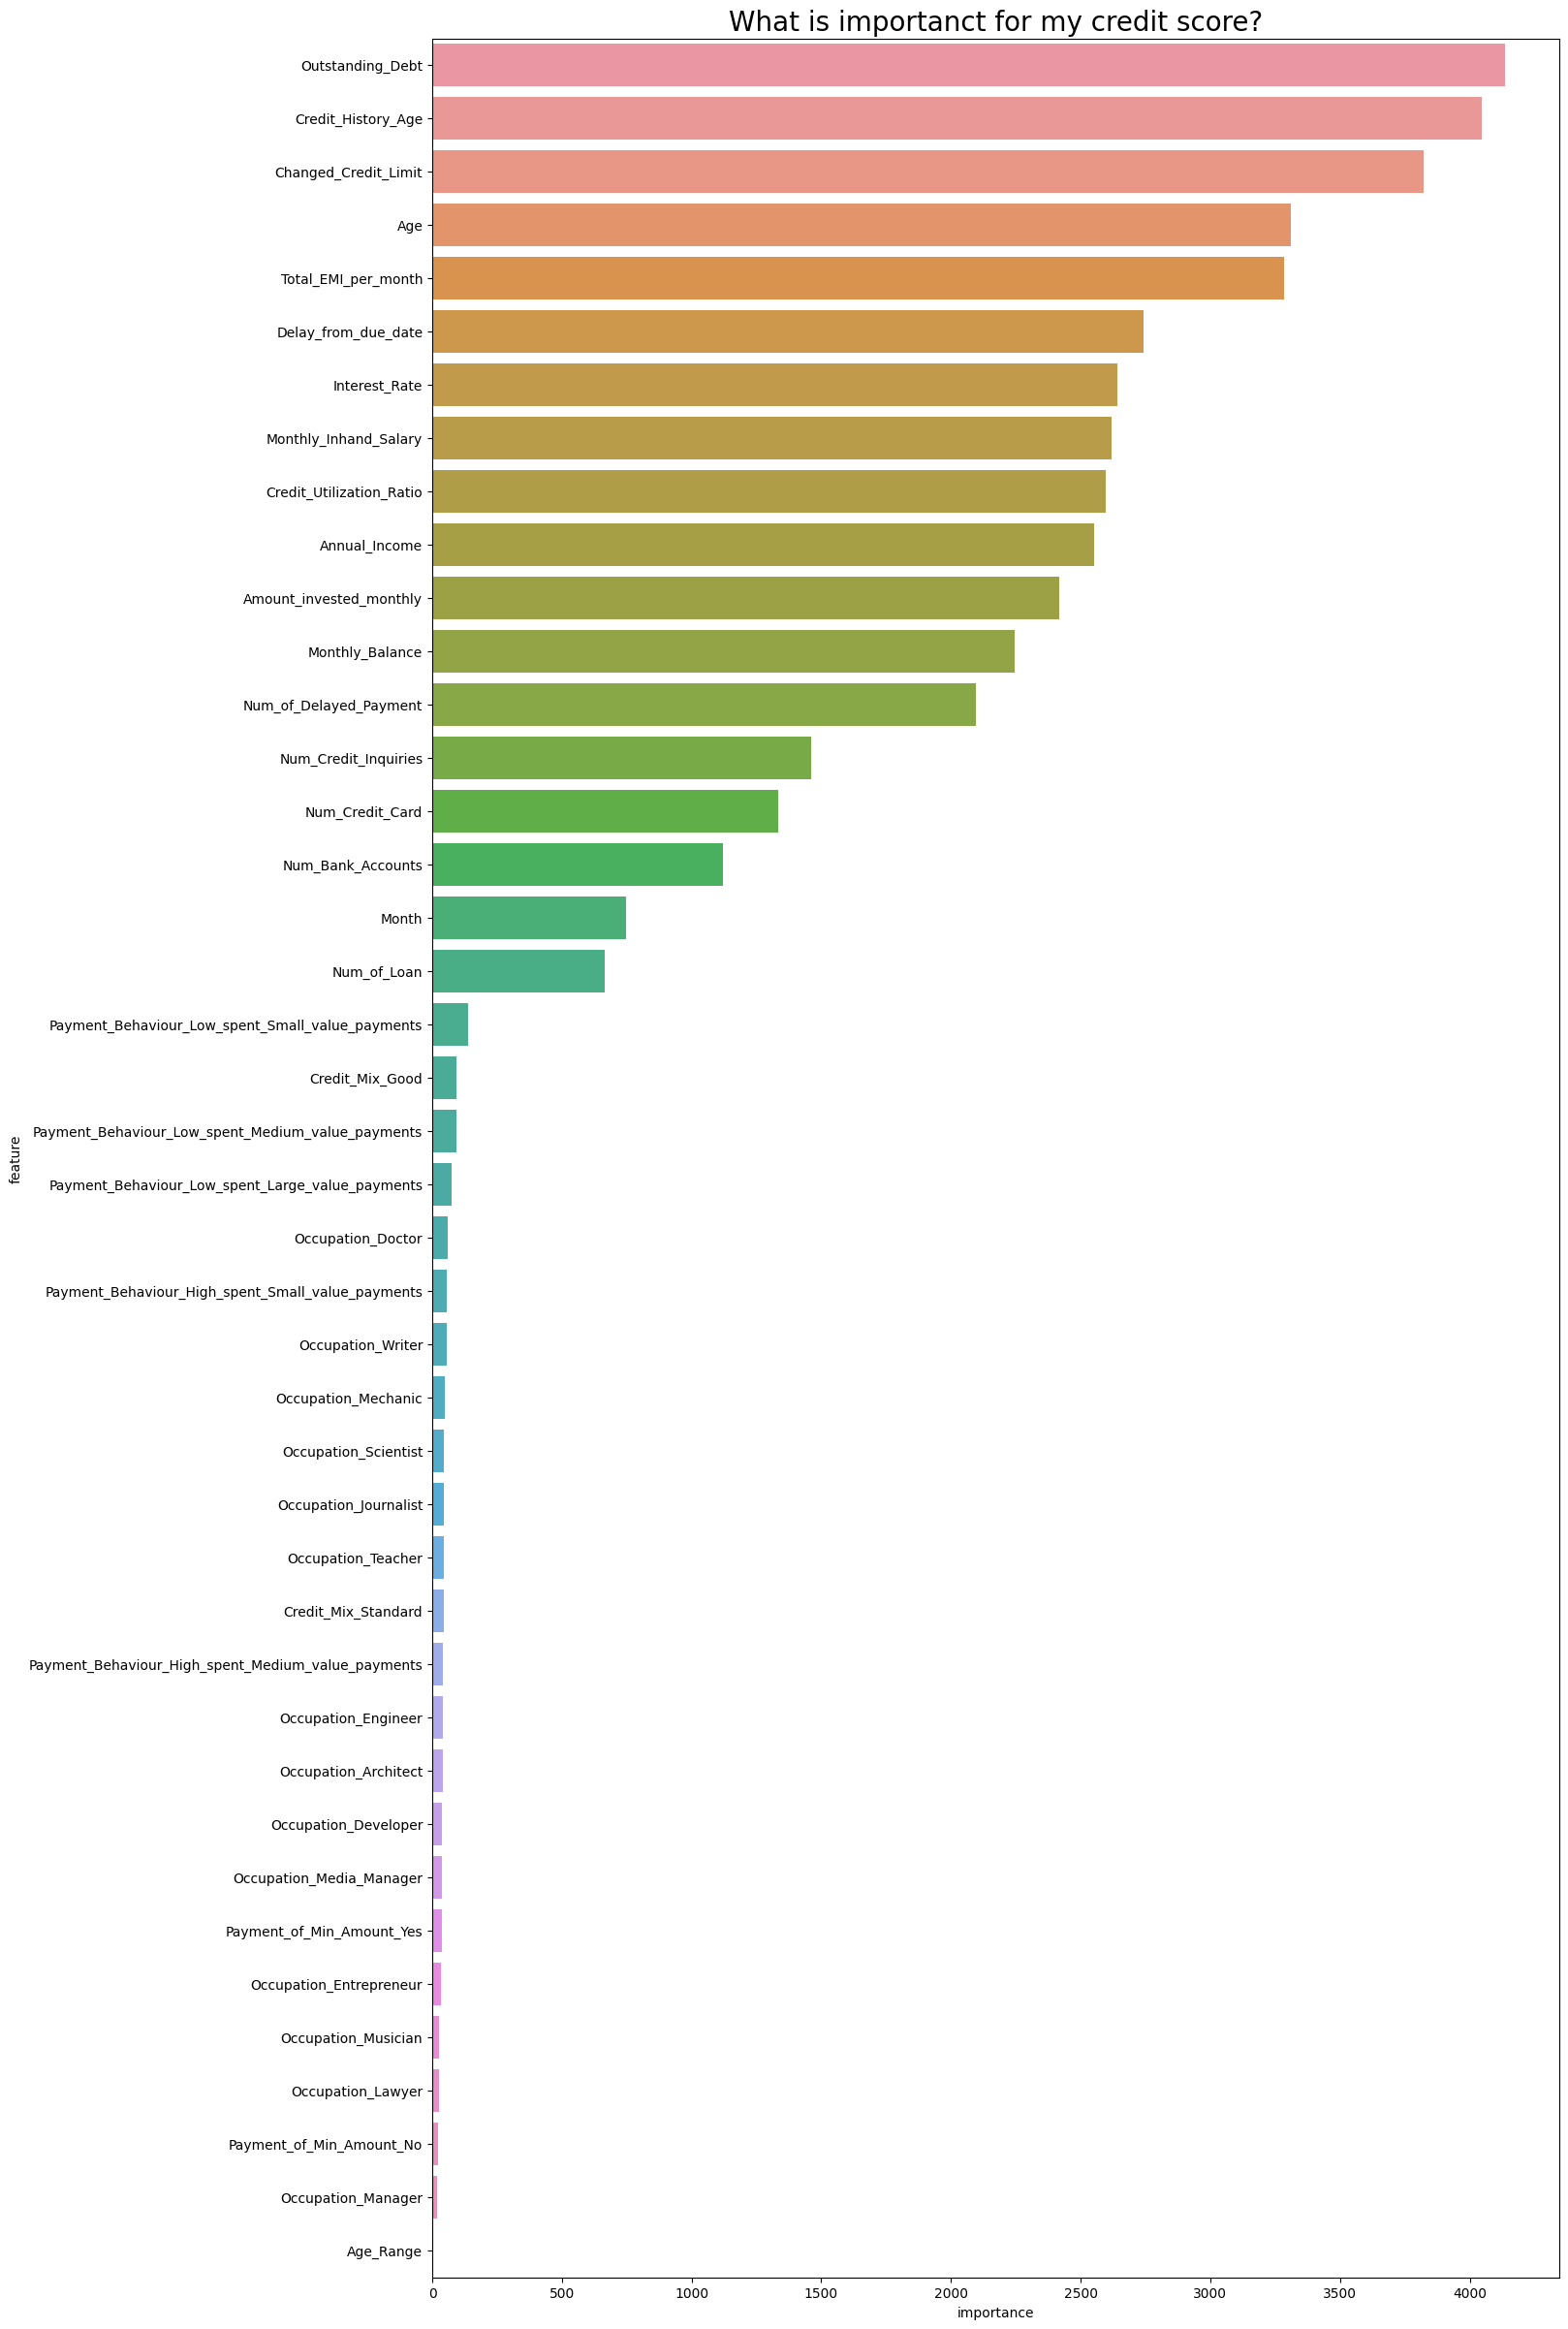

In [ ]:
Fimp = pd.DataFrame({"feature": X.columns, "importance":search.best_estimator_.feature_importances_}).sort_values("importance", ascending=False)

plt.figure(figsize=(15,30))
sns.barplot(x="importance", y="feature", data=Fimp)
plt.title("What is importanct for my credit score?", fontsize=20)
plt.show()

1. These are the most important features for model learning in the order of total monthly EMI, outstanding debt, and Credit history age.
2. Most of the occpation values and Age Range values did not affect model learning.
3. There are some things that we expected, but we can see that things that we didn't expect have a big impact on our credit score classification.

In [ ]:
search.best_score_

0.7973125

# Prediction

In [ ]:
# Make the default LGBM Model, then training and testing
search2 = model_pre.fit(X_train, y_train)
y_pred2 = search2.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           1       0.76      0.70      0.73      5694
           2       0.78      0.77      0.78     10649
           3       0.64      0.75      0.69      3657

    accuracy                           0.75     20000
   macro avg       0.73      0.74      0.73     20000
weighted avg       0.75      0.75      0.75     20000



In [ ]:
X_test.shape

(20000, 42)

In [ ]:
y_pred = search.predict(X_test)

In [ ]:
X_test.head()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Writer,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
98468,5,38.0,43135.98,3375.665000,8.0,4.0,18.0,2.0,29.0,7.0,...,0,0,1,0,1,0,0,1,0,0
17224,1,53.0,17572.15,1575.345833,3.0,5.0,18.0,4.0,22.0,10.0,...,0,0,1,0,1,0,0,1,0,0
72270,7,33.0,16218.32,1098.526667,6.0,6.0,21.0,5.0,46.0,20.0,...,0,0,0,0,1,0,0,1,0,0
35430,7,38.0,69228.92,5752.076667,9.0,8.0,18.0,7.0,48.0,16.0,...,0,0,0,0,1,0,0,0,0,1
48482,3,32.0,46297.44,3806.120000,7.0,8.0,26.0,9.0,62.0,18.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83      5694
           1       0.85      0.82      0.84     10649
           2       0.79      0.81      0.80      3657

    accuracy                           0.83     20000
   macro avg       0.82      0.82      0.82     20000
weighted avg       0.83      0.83      0.83     20000



In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Average macro F1 : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred, average='macro'):.3f}")

Accuracy : 0.826
Average macro F1 : 0.820
Average macro Recall : 0.824
Average macro Precision : 0.816


In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred2):.3f}")
print(f"Average macro F1 : {f1_score(y_test, y_pred2, average='macro'):.3f}")
print(f"Average macro Recall : {recall_score(y_test, y_pred2, average='macro'):.3f}")
print(f"Average macro Precision : {precision_score(y_test, y_pred2, average='macro'):.3f}")

Accuracy : 0.748
Average macro F1 : 0.733
Average macro Recall : 0.740
Average macro Precision : 0.729


# K-Fold

In [ ]:
non_numerical_columns = df.select_dtypes(exclude=[np.number]).columns
numerical_columns = df[df.columns[df.columns != "Credit_Score"]].select_dtypes(include=[np.number]).columns

transformed_features = [df[numerical_columns].to_numpy()]
for column in non_numerical_columns:
  if column == "Credit_Score":
    continue
  transformed_features.append(LabelEncoder().fit_transform(df[column]).reshape((-1, 1)))

X = np.hstack(transformed_features)
le = LabelEncoder()
y = le.fit_transform(df["Credit_Score"])

In [5]:
kf = KFold(n_splits=10, shuffle=True)
acc = []
f1_macro = []
recall_macro = []
precision_macro = []
metrics = []
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    model.fit(X[train_index], y[train_index])
    y_pred = model.predict(X[test_index])
    print(classification_report(y[test_index], y_pred))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(model.score(X[test_index], y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))

print("Mean accuray:", np.mean(acc))

Fold 0:
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1779
           1       0.81      0.84      0.82      2886
           2       0.85      0.83      0.84      5335

    accuracy                           0.82     10000
   macro avg       0.81      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000


Fold 1:
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1742
           1       0.80      0.83      0.81      2882
           2       0.84      0.82    

#### Evaluation results on K-Fold

In [7]:
print(f"Average macro F1 : {round(np.mean(f1_macro), 3)}")
print(f"Average macro Recall : {round(np.mean(recall_macro), 3)}")
print(f"Average macro Accuracy:", round(np.mean(acc), 3))
print(f"Average macro Precision : {round(np.mean(precision_macro), 3)}")

Average macro F1 : 0.819
Average macro Recall : 0.823
Average macro Accuracy: 0.825
Average macro Precision : 0.816
